# The Trace-Projection Trade: Dummy-Triangle Embeddings of the 19-Site Kagome Antiferromagnet

**Assignment (verbatim).** *"This is probably the last task, an application of the
dummy qubits. I have embedded three / 6 dummy qubits forming blue triangles. The black
triangles are original Kagome lattice. So now we have converted our original problem to
bigger problem. Your goal is the same as the original task, task-1 (attempt to generate
spin liquid state) on the black part of the bigger problem within the new construction.
Obviously, this should be somewhat easy as we can transfer dimers on dummy (blue)
triangles to the black ones. Number the dummy qubits as you like, but trace them out at
the last step. Then see if black part can closely model spin-liquid state."*

(On *"three / 6"*: three dummy triangles, each contributing an apex and a primed
copy = **6** dummy **qubits**; the third vertex of each blue triangle is a pre-existing
black site. $19+6=25$ — the same arithmetic as Task 4.)

**Verdict.** The black part *can* closely model the spin-liquid state, but only in the
projected reading. Under the literal trace it can match the energy only by spending its
entire 1-bit budget and surrendering purity, and a spin liquid is a pure state with
$\langle S^2\rangle = 3/4$, which is precisely what the trace cannot deliver while the
dummies do anything at all.

| § | Content | Role |
|---|---|---|
| 1 | Prop. 1-2 — five insertion triplets; $2T-N=+1$; 0 covers; six virtual bonds | geometry |
| 2 | Prop. 3 — the $-27$ product ceiling; the Theorem-5 trap; the naive DnC bound | baselines |
| 3 | Lemma B (general $\log_2 d$ budget) + corollary $d=2$ | trace side |
| 4 | Theorem P (general Bell channel) + exact rational corollary + Gram criterion | projection side |
| 5 | ed25 — the exact 25-qubit ground state | benchmark |
| 6 | The trade curve $k=0..3$ | central figure |
| 7 | Prop. 8 — the cut identity $a_3 = E_0(H_{19}\setminus\text{cut})$ and the design rule | mechanism |
| 8 | Prop. 7 — one lattice, five readouts; does the advantage survive? | control |
| 9 | Head-to-head at equal parameters | variational test |
| 10 | Lemma J, the swap identity and Prop. 9 — the three routes to a *preparable* good state, all closed | the open path |
| 11 | Discussion: 1 bit vs the 3.15 bits a spin liquid needs | closure |
| 12 | Summary, five-task arc, reconciliation of preliminary numbers | deliverable |

Every claim carries executable `assert`s; heavy artifacts persist in `results/*.npz` and
auto-load. Engines: Tasks 1-4 imported; the Task-5 layer is
[`kagome_trade.py`](kagome_trade.py).

In [21]:
# --- Environment: reuse Tasks 1-4 wholesale; the Task-5 layer is kagome_trade ---
import sys, time
from pathlib import Path
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

HERE = Path.cwd()
if not (HERE / "kagome_trade.py").exists():        # kernel started elsewhere
    HERE = Path("/home/tesla/Qintern2026/5_Task")
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import kagome_trade as kt    # Task-5 module (this folder); pulls in the engines below
import kagome_hva as K       # Task-1 engine
import kagome_dc as dc       # Task-2 engine (blocked kernels, RecombinationVQE)
import kagome_er as er       # Task-3 engine (dimer_cover_state)
import kagome_delta as kd    # Task-4 engine (manifolds, contraction map)

RESULTS, FIGURES = HERE / "results", HERE / "figures"
RESULTS.mkdir(exist_ok=True); FIGURES.mkdir(exist_ok=True)
RECOMPUTE_HEAVY = False      # True re-runs every heavy artifact in-notebook

BLUE, GREEN, RED, GRAY = "#2a78d6", "#1baf7a", "#e34948", "#8a8a86"
np.set_printoptions(precision=4, suppress=True)
TOL = 1e-9

def assert_close(x, y, tol=TOL, msg=""):
    assert abs(x - y) < tol, f"{msg}: {x} vs {y}"

E19, V19 = kt.load_doublet()          # exact 19-site doublet (re-orthonormalized)
assert_close(E19, kt.E19_REF, 1e-6, "ed19")
err = lambda E: 100.0 * abs(E - E19) / abs(E19)
E_T2, E_T3 = 3.932, 0.938             # Task-2 partition / Task-3 best DnC (err %)
print(f"engines loaded; E19 = {E19:.6f} (doublet, dim {V19.shape[1]})")

engines loaded; E19 = -29.146168 (doublet, dim 2)


## 1. Where dummies can go, and the canonical construction

A dummy triangle is inserted at a corner site $c$ (a site shared by two black
triangles): $c$ keeps one triangle, a primed copy $c'$ takes the other, and the blue
triangle $(c,\text{apex},c')$ bridges them; 2 new sites and 1 new triangle per
insertion, exactly the Task-4 move. Three insertions cut the 10-triangle adjacency graph
(a ring with one chord through site 11) into two 5-triangle open chains.

> **Proposition 1.** Of the $\binom{11}{3}=165$ corner triplets, *exactly five* split
> the network into two `delta_chain(5)` fragments: $(1,10,11)$, $(2,11,12)$,
> $(4,11,14)$, $(6,11,16)$, $(8,11,17)$, each must contain 11 (the chord must be cut)
> plus two antipodal ring cuts. Advisor's figure draws $(6,11,16)$; that is the canonical
> choice below, with the primed copies joining the fragment of site 0.

*Two implementation traps, both caught here and documented in the module: the scan must
vertex-split corners per triangle (corners 2 and 11 share triangle $(1,2,11)$, and
an edge-based split silently loses $(2,11,12)$), and the lattice builder must apply the
three insertions *simultaneously* (in the shared-host cases of §8 one triangle
receives two primed copies, which sequential per-corner edits corrupt).*

> **Proposition 2 (frustration is relocated, not removed).** The 25-site lattice has
> $N=25$, 39 bonds, $T=13$: $2T-N=+1$, identical to the original, the Task-4
> counting invariant is conserved by construction, so the cover witness still fails:
> **0** valid dimer covers out of $3^{13}$. Six of the 30 $H_{19}$ bonds become
> **virtual**; absent from the 25-site lattice, mediated only through the blue
> triangles: $(1,11),(2,11),(4,6),(5,6),(16,17),(16,18)$. Activating them *is* the test
> of the construction.

Qubit layout, fixed throughout: black sites keep their Task-1 labels $0..18$; dummy pair
$k$ = (apex, copy) = $(19{+}2k,\,20{+}2k)$, corners sorted, so $\rho_{\rm black}$ is
always the trace over the top six qubits, and is never formed explicitly (the view
$M=\psi.\mathrm{reshape}(2^6,2^{19})$ carries its whole spectrum; the matrix would be
4 TB).

In [22]:
# Prop. 1 + Prop. 2: exhaustive scan, canonical insertion, invariants ------------
t0 = time.perf_counter()
trips = kt.splitting_triplets()                      # 165-triplet exhaustive scan
assert trips == kt.SPLITTING_TRIPLETS and kt.CANONICAL in trips
print(f"splitting triplets ({len(trips)}/165): {trips}")

ins = kt.insert_dummies()            # every geometric invariant asserted inside
fd  = kt.fragment_data(ins)
assert ins.pairs == [(19, 20), (21, 22), (23, 24)]
assert ins.hosts == {6: (4, 5, 6), 11: (1, 2, 11), 16: (16, 17, 18)}
print(f"canonical {ins.triplet}: {len(ins.edges)} bonds, {len(ins.triangles)} "
      f"triangles, 2T-N = {2 * len(ins.triangles) - 25:+d}")
print(f"virtual bonds  : {ins.virtual}")
print(f"black fragment : {ins.frag_black}  (all-black delta_chain(5))")
print(f"mixed fragment : {ins.frag_mixed}  (8 black + 3 primed)")

covers25, total25 = kd.enumerate_covers(ins.triangles)
assert len(covers25) == 0 and total25 == 3 ** 13
print(f"dimer covers on the 25-site lattice: {len(covers25)} / {total25:,} "
      f"-> the Task-4 witness fails, frustration survives  "
      f"[{time.perf_counter() - t0:.1f} s]")

splitting triplets (5/165): [(1, 10, 11), (2, 11, 12), (4, 11, 14), (6, 11, 16), (8, 11, 17)]
canonical (6, 11, 16): 39 bonds, 13 triangles, 2T-N = +1
virtual bonds  : [(1, 11), (2, 11), (4, 6), (5, 6), (16, 17), (16, 18)]
black fragment : [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]  (all-black delta_chain(5))
mixed fragment : [0, 1, 2, 3, 4, 5, 17, 18, 20, 22, 24]  (8 black + 3 primed)
dimer covers on the 25-site lattice: 0 / 1,594,323 -> the Task-4 witness fails, frustration survives  [1.9 s]


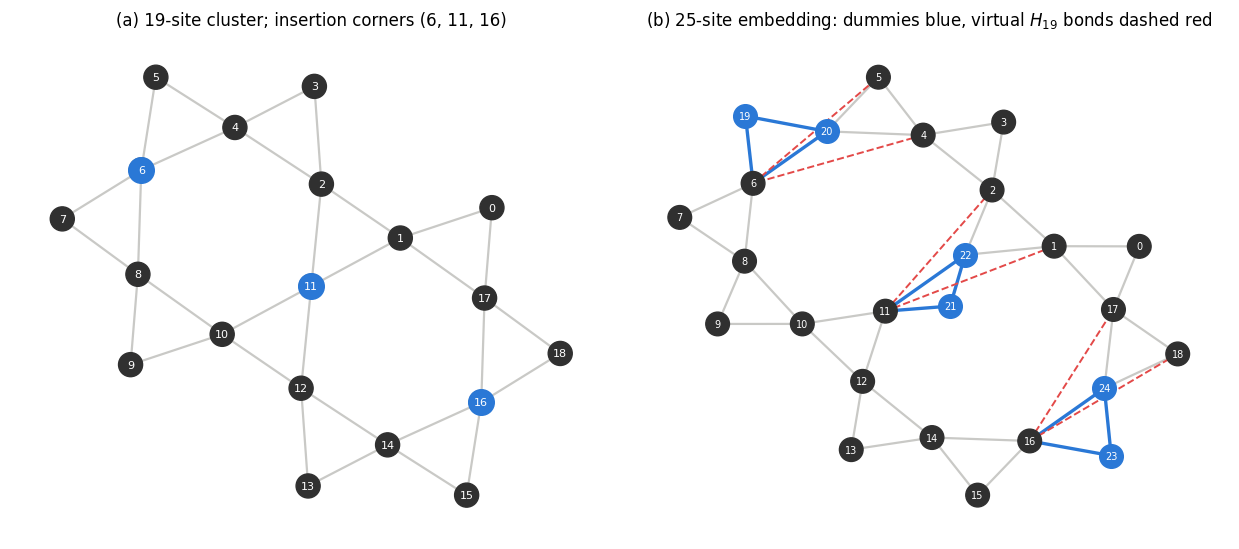

In [23]:
# --- Fig. 1: the canonical embedding -------------------------------------------
G25 = nx.Graph(ins.edges)
pos = nx.kamada_kawai_layout(G25)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6))

ax = axes[0]                                   # (a) the 19-site original
G19 = nx.Graph(kt.EDGES19)
p19 = nx.kamada_kawai_layout(G19)
nx.draw_networkx_edges(G19, p19, edge_color="#c9c9c6", width=1.6, ax=ax)
nx.draw_networkx_nodes(G19, p19, node_color=["#303030"] * 19, node_size=300, ax=ax)
nx.draw_networkx_nodes(G19, p19, nodelist=list(kt.CANONICAL), node_color=BLUE,
                       node_size=340, ax=ax)
nx.draw_networkx_labels(G19, p19, font_size=8, font_color="white", ax=ax)
ax.set_title("(a) 19-site cluster; insertion corners (6, 11, 16)")

ax = axes[1]                                   # (b) the 25-site embedding
plain = [e for e in ins.edges if e not in ins.dummy_edges]
nx.draw_networkx_edges(G25, pos, edgelist=plain, edge_color="#c9c9c6",
                       width=1.6, ax=ax)
nx.draw_networkx_edges(G25, pos, edgelist=ins.dummy_edges, edge_color=BLUE,
                       width=2.4, ax=ax)
nx.draw_networkx_edges(nx.Graph(list(ins.virtual)), pos, edge_color=RED,
                       width=1.4, style="dashed", ax=ax)
blacks = [v for v in G25.nodes if v <= 18]
nx.draw_networkx_nodes(G25, pos, nodelist=blacks,
                       node_color=["#303030"] * len(blacks), node_size=290, ax=ax)
nx.draw_networkx_nodes(G25, pos, nodelist=[v for v in G25.nodes if v > 18],
                       node_color=BLUE, node_size=290, ax=ax)
nx.draw_networkx_labels(G25, pos, font_size=7, font_color="white", ax=ax)
ax.set_title("(b) 25-site embedding: dummies blue, virtual $H_{19}$ bonds "
             "dashed red")
for ax in axes:
    ax.set_axis_off()
fig.tight_layout()
fig.savefig(FIGURES / "fig1_embedding.png", dpi=160, bbox_inches="tight")
plt.show()

## 2. Depth-0 floors: what costs nothing, and what it buys

Three product-level strategies, all scored against the *black target*
$E_{19}=-29.146168$. Design decision, fixed for the whole task: the objective is
$\langle H_{19}\rangle$ *evaluated on the 25-qubit state* (the 30 original bonds,
virtual ones included), *not* $\langle H_{25}\rangle$. The penalty for optimizing the
wrong functional is measured below: 16.07% (a2) vs 5.08% (a3).

> **Proposition 3 (the product ceiling).** For a product of singlet dimers,
> $\mathrm{Tr}(\rho_{\rm black}h_{ij})=-3$ exactly when $(i,j)$ is a dimer on a
> black-black $H_{19}$ bond, else $0$. The 25-site lattice has *72* maximum matchings;
> their black-dimer distribution is $9\to17$, $8\to22$, $7\to25$, $6\to8$, so the best
> dimer product gives $\langle H_{19}\rangle=-27$ , *exactly the bare 19-site dimer
> floor*, since the black maximum matching is the original 9 regardless of the
> insertion. At depth 0 the six dummy qubits buy *nothing*.

> **The Theorem-5 trap (a2).** Theorem 5 invites using the *exact* chain ground states
> (both fragments are exactly solvable, $E_0=-15$, deg 12). But the mixed chain spends 6
> of its 15 bonds on primed copies that the trace discards. Best over the full
> $12\times12$ manifolds: $-24.4619$ (16.07%) at zero polarization, $-24.4858$ (15.99%)
> once virtual-bond polarization cross terms are exploited. *Being optimal on the
> enlarged lattice is the worst of the three depth-0 strategies.*

> **The naive DnC bound (a3).** Optimizing the same fragment structure against the black
> target: $-15 - 12.665016 = -27.665016$ (5.082%), pure, $\langle S^2\rangle = 3/4$
> exactly. (Task-2's engineered partition reached 3.93%; §7-8 explain the gap and beat
> both.)

In [24]:
# (a1) / (a2) / (a3), all asserted -----------------------------------------------
a1 = kt.best_cover_baseline(ins)
assert (a1["n_matchings"], a1["best_black"]) == (72, 9)
assert a1["distribution"] == {9: 17, 8: 22, 7: 25, 6: 8}
print(f"(a1) 72 maximum matchings, black-dimer distribution "
      f"{dict(sorted(a1['distribution'].items(), reverse=True))} "
      f"-> best <H19> = {a1['energy']:.4f}  ({err(a1['energy']):.3f}%)")

a3 = kt.naive_dnc_bound(ins)
assert_close(a3["energy"], -27.665016, 5e-6, "(a3)")
assert a3["deg_rest"] == 1
print(f"(a3) {a3['E_chain']:.4f} + {a3['E_black_rest']:.6f} = "
      f"{a3['energy']:.6f}  ({err(a3['energy']):.3f}%)   [8 black sites, "
      f"{a3['n_rest_bonds']} bonds, non-degenerate]")

t0 = time.perf_counter()
a2 = kt.chain_product_baseline(ins, n_starts=6, iters=40, seed=0)
assert_close(a2["energy_nocross"], -24.461865, 1e-6, "(a2) no-cross")
assert a2["energy"] < -24.47
print(f"(a2) exact-chain product: no-cross = {a2['energy_nocross']:.6f} "
      f"({err(a2['energy_nocross']):.3f}%), with polarization = "
      f"{a2['energy']:.4f} ({err(a2['energy']):.3f}%)   "
      f"[{time.perf_counter() - t0:.0f} s]")
print(f"     at the optimum: mixed-fragment purity {a2['purity']:.3f}, "
      f"S(black|blue) = {a2['entropy']:.4f} bits, <S2_black> = "
      f"{a2['s2_black']:.4f}")

psi_cover = er.dimer_cover_state(25, [tuple(d) for d in a1["matching"]])
assert_close(kt.h19_energy(psi_cover, 25), -27.0, 1e-9, "cover statevector")
print("(a1) statevector cross-check on the best cover: <H19> = -27.0000  ok")

(a1) 72 maximum matchings, black-dimer distribution {9: 17, 8: 22, 7: 25, 6: 8} -> best <H19> = -27.0000  (7.363%)


(a3) -15.0000 + -12.665016 = -27.665016  (5.082%)   [8 black sites, 9 bonds, non-degenerate]
(a2) exact-chain product: no-cross = -24.461865 (16.072%), with polarization = -24.4858 (15.990%)   [0 s]
     at the optimum: mixed-fragment purity 0.193, S(black|blue) = 2.5533 bits, <S2_black> = 2.1960
(a1) statevector cross-check on the best cover: <H19> = -27.0000  ok


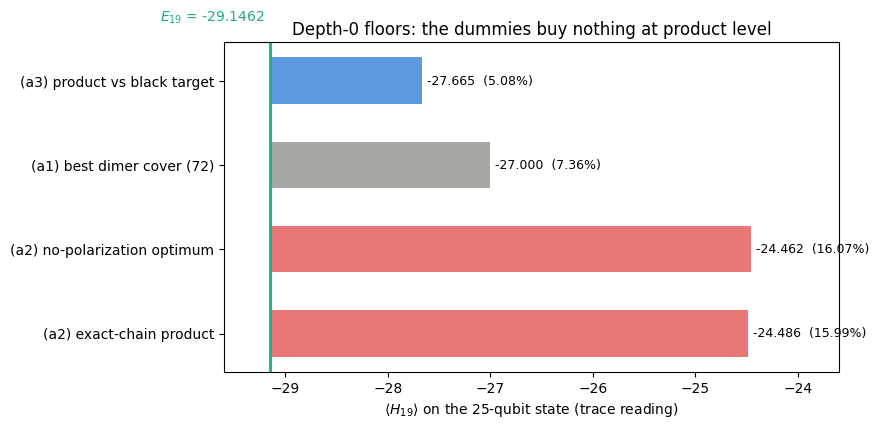

In [25]:
# --- Fig. 2: the depth-0 ladder --------------------------------------------------
fig, ax = plt.subplots(figsize=(8.8, 4.4))
rows = [("(a2) exact-chain product",     a2["energy"],         RED),
        ("(a2) no-polarization optimum", a2["energy_nocross"], RED),
        ("(a1) best dimer cover (72)",   a1["energy"],         GRAY),
        ("(a3) product vs black target", a3["energy"],         BLUE)]
ys = np.arange(len(rows))
for y, (label, E, c) in zip(ys, rows):
    ax.barh(y, E - E19, left=E19, color=c, alpha=0.75, height=0.55)
    ax.text(E + 0.05, y, f"{E:.3f}  ({err(E):.2f}%)", va="center", fontsize=9)
ax.axvline(E19, color=GREEN, lw=2)
ax.text(E19 - 0.05, len(rows) - 0.3, f"$E_{{19}}$ = {E19:.4f}", color=GREEN,
        ha="right", fontsize=10)
ax.set_yticks(ys, [r[0] for r in rows])
ax.set_xlabel(r"$\langle H_{19}\rangle$ on the 25-qubit state (trace reading)")
ax.set_xlim(-29.6, -23.6)
ax.set_title("Depth-0 floors: the dummies buy nothing at product level")
fig.tight_layout()
fig.savefig(FIGURES / "fig2_depth0.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Lemma B — the entanglement budget of the trace reading

State it once, in general form; the 1 bit of this problem is then a corollary, not a
coincidence of the lattice.

> **Lemma B (budget of a traced readout).** Let $H$ act on a system $S$ with ground
> energy $E_0$ and ground manifold $\mathcal G$ of dimension $d$, and let
> $\rho=\mathrm{Tr}_A|\Psi\rangle\langle\Psi|$ for any pure state of $S\otimes A$. Since
> $H-E_0\succeq0$ with kernel exactly $\mathcal G$,
> $$\mathrm{Tr}(\rho H)=E_0\iff \mathrm{supp}\,\rho\subseteq\mathcal G
> \implies \mathrm{rank}\,\rho\le d\implies S(S|A)\le\log_2 d\ \text{bits},
> \quad \mathcal P(\rho)\ge 1/d .$$
> The bound is *tight*: $|\Psi^\ast\rangle=d^{-1/2}\sum_k|g_k\rangle|k\rangle_A$
> attains $\mathrm{Tr}(\rho H)=E_0$ with $\rho=P_{\mathcal G}/d$ ; entropy exactly
> $\log_2 d$, purity exactly $1/d$.
>
> **Corollary (this problem, $d=2$).** The 19-site ground manifold is a single doublet,
> so an exact traced readout may carry *at most 1 bit* of black-blue entanglement, and
> its purity is at least $1/2$.
>
> **Corollary (dichotomy).** Exact and pure $\iff$
> $|\Psi\rangle=|g\rangle\otimes|\chi\rangle$: the dummies factorize and are inert (their
> only residual effect on $\langle H_{19}\rangle$ is the polarization product on the six
> virtual bonds). Within the trace reading, exactness and non-trivial dummy entanglement
> are mutually exclusive beyond one bit.

The budget state $|\Psi^\ast\rangle$ is worth staring at: it *is* exact in energy, but
$\rho$ is the maximally mixed doublet ; an unpolarized $T\to0$ ensemble, *not* a
wavefunction. Purity, not energy, is what the trace can never deliver together with
dummy entanglement. For scale, the (a2) optimum already spends 2.55 bits, 2.5 $\times$
the budget, which is exactly why it pays 16%.

In [26]:
# Lemma B: general family (d = 4, 6, 8) and the d = 2 instance -------------------
specs = [(f"delta_chain({m})",) + kd.delta_chain(m)[:2] for m in (1, 2, 3)]
fam = kt.lemma_b_family([(lab, n, e) for lab, n, e in specs])
print(f"{'cluster':16s} {'n':>2s} {'d':>2s} {'E0':>7s} {'Tr(rho H)':>10s} "
      f"{'purity':>8s} {'1/d':>7s} {'S bits':>8s} {'log2 d':>7s} "
      f"{'rank+1 E':>9s}")
for r in fam:
    print(f"{r['label']:16s} {r['n']:2d} {r['d']:2d} {r['E0']:7.3f} "
          f"{r['E_budget']:10.6f} {r['purity']:8.6f} {1 / r['d']:7.4f} "
          f"{r['entropy']:8.6f} {r['log2d']:7.4f} {r['E_rank_excess']:9.4f}")
    assert_close(r["E_budget"], r["E0"], 1e-9, "budget energy")
    assert_close(r["purity"], 1 / r["d"], 1e-12)
    assert_close(r["entropy"], r["log2d"], 1e-12)
    assert r["rank"] == r["d"] and r["E_rank_excess"] > r["E0"] + 1e-6
print("  -> S = log2(d) exactly for d = 4, 6, 8, and leaving the manifold "
      "raises the energy   [general Lemma B verified]")

# the d = 2 corollary, on the real system (19 black + 6 dummy qubits)
psi_star = kt.budget_state(V19, n_anc=6)
mB = kt.black_moments(psi_star, 25, V19=V19)
print(f"\nd = 2 corollary, |Psi*> on 25 qubits:")
print(f"  Tr(rho H19) = {mB['energy']:.6f}  (E19 = {E19:.6f})")
print(f"  purity {mB['purity']:.4f} (= 1/2), S(black|blue) = "
      f"{mB['entropy']:.4f} bits (= log2 2), rank {mB['rank']}, <S2> = "
      f"{mB['s2_black']:.4f}, doublet weight = {mB['doublet_weight']:.6f}")
for val, ref in ((mB["energy"], E19), (mB["purity"], 0.5),
                 (mB["entropy"], 1.0), (mB["s2_black"], 0.75),
                 (mB["doublet_weight"], 1.0)):
    assert_close(val, ref, 1e-6, "budget state")
assert mB["rank"] == 2
del psi_star
print("  exact in energy, maximally mixed in the doublet: a T->0 ensemble, "
      "not a spin-liquid wavefunction")

cluster           n  d      E0  Tr(rho H)   purity     1/d   S bits  log2 d  rank+1 E
delta_chain(1)    3  4  -3.000  -3.000000 0.250000  0.2500 2.000000  2.0000   -1.5000
delta_chain(2)    5  6  -6.000  -6.000000 0.166667  0.1667 2.584963  2.5850   -5.6667
delta_chain(3)    7  8  -9.000  -9.000000 0.125000  0.1250 3.000000  3.0000   -8.8173
  -> S = log2(d) exactly for d = 4, 6, 8, and leaving the manifold raises the energy   [general Lemma B verified]

d = 2 corollary, |Psi*> on 25 qubits:
  Tr(rho H19) = -29.146168  (E19 = -29.146168)
  purity 0.5000 (= 1/2), S(black|blue) = 1.0000 bits (= log2 2), rank 2, <S2> = 0.7500, doublet weight = 1.000000
  exact in energy, maximally mixed in the doublet: a T->0 ensemble, not a spin-liquid wavefunction


## 4. Theorem P — the projection channel and its exact price

Again the general statement first; the rationals of this cluster are its corollary.

> **Theorem P (Bell readout of a dummy pair).** Let $\mathcal G$ be an SU(2)-invariant
> ground manifold, $P=P_{\mathcal G}$, and let $K_b$ be the contraction of a dummy pair
> (apex, primed copy) against Bell bra $b\in\{s,t_0,t_+,t_-\}$. Then
> 1. **Covariance.** $K_s$ is SU(2)-*equivariant*, $K_sU^{\otimes n}=U^{\otimes(n-2)}K_s$
>    — the singlet bra is the unique SU(2) invariant of two spins — and it coincides with
>    Task-4's contraction map $R$. The three triplet bras span the spin-1 irrep and are
>    permuted among themselves, so their channel data are equal by symmetry.
> 2. **Statistics.** $p_b=\mathrm{tr}(K_bPK_b^\dagger)/\dim\mathcal G$ and the image
>    weight $w_b=\mathrm{tr}(P_{\rm target}K_bPK_b^\dagger)/\mathrm{tr}(K_bPK_b^\dagger)$
>    are basis-invariant (functions of $P$ alone).
> 3. **Correctability (Gram criterion).** Branch $b$ is repairable by any $b$-conditioned
>    unitary or isometry on the survivors **iff** its normalized Gram matrix
>    $\hat G_b\propto (K_bV)^\dagger(K_bV)$ equals $\hat G_s$. Deviation $\Rightarrow$ no
>    feed-forward correction exists.
>
> **Corollary (Task-4 miniature, exact rationals).**
> $$p_s=\tfrac{9}{16},\quad p_{t_0}=p_{t_+}=p_{t_-}=\tfrac{7}{48};\qquad
> w_s=1,\quad w_{t_0}=w_{t_+}=w_{t_-}=\tfrac{13}{21}.$$
> The triplet branches all lose exactly $8/21$ of their weight outside the target
> manifold, and $\|\hat G_t-\hat G_s\|_F>0$ for all three: *the postselection cost is
> real and uncorrectable.*

**These are exact, not fitted.** $H$ has integer entries and $E_0$ is an integer, so
$\ker(H-E_0)$ is a *rational* subspace: the manifold projector has rational entries and
every trace above is a rational number. The cell below builds those projectors by exact
Gauss-Jordan over $\mathbb Q$ (`fractions.Fraction`, no eigensolver, no floating point
anywhere) and returns the fractions verbatim; the float pipeline is then shown to agree
to $10^{-10}$.

*Reconciliation:* an earlier prelim of this task recorded triplet weights $5/9,4/9,4/9$.
Those came from a basis-dependent per-column average and are superseded by the
invariant value $13/21$ for all three channels.

In [27]:
# Theorem P: exact rational arithmetic, then the float cross-check ---------------
t0 = time.perf_counter()
exact = kt.exact_bell_table()
print(f"EXACT rational Bell table (Fraction arithmetic on the rational "
      f"kernel projectors, {time.perf_counter() - t0:.2f} s):")
for name, (p, w) in exact.items():
    print(f"  {name:9s}:  p = {str(p):>5s} = {float(p):.10f}     "
          f"weight = {str(w):>5s} = {float(w):.10f}")
assert exact["singlet"] == (Fraction(9, 16), Fraction(1))
for t in ("triplet0", "triplet+", "triplet-"):
    assert exact[t] == (Fraction(7, 48), Fraction(13, 21))
assert sum(p for p, _ in exact.values()) == 1
print(f"  probabilities sum to exactly {sum(p for p, _ in exact.values())}, "
      f"and 3 x 7/48 + 9/16 = 1 as rationals")

# float channel data (general Theorem P machinery) + Gram criterion
_, Vm7, _ = kd.ground_manifold(7, kd.MOD_EDGES)
_, Vo5, _ = kd.ground_manifold(5, kd.ORIG_EDGES)
Po5 = Vo5 @ Vo5.conj().T
chan = kt.bell_channel_data(Vm7, 7, kd.DUMMY_PAIR, P_target=Po5)
gram_dev = kt.gram_distance(chan)
print(f"\n{'branch':9s} {'p (float)':>10s} {'|p-exact|':>10s} "
      f"{'weight':>9s} {'|w-exact|':>10s} {'||Ghat-Ghat_s||':>16s}")
for name in ("singlet", "triplet0", "triplet+", "triplet-"):
    pe, we = exact[name]
    c = chan[name]
    print(f"{name:9s} {c['p']:10.6f} {abs(c['p'] - float(pe)):10.2e} "
          f"{c['weight']:9.6f} {abs(c['weight'] - float(we)):10.2e} "
          f"{gram_dev[name]:16.4f}")
    assert abs(c["p"] - float(pe)) < 1e-10 and abs(c["weight"] - float(we)) < 1e-10
assert all(gram_dev[t] > 0.05 for t in ("triplet0", "triplet+", "triplet-"))
assert gram_dev["singlet"] < 1e-12

res_equiv = kt.su2_equivariance_residual(7, kd.DUMMY_PAIR)
print(f"\nSU(2) equivariance of the singlet branch: ||K_s U^(x)7 - U^(x)5 K_s|| "
      f"= {res_equiv:.2e}")
assert res_equiv < 1e-12
v, p, _ = kt.project_pairs(Vm7[:, 0], 7, {tuple(kd.DUMMY_PAIR): "singlet"})
assert np.allclose(v * np.sqrt(p), kd.contraction_map() @ Vm7[:, 0], atol=1e-12)
print("singlet channel == kd.contraction_map, state by state  ok")

EXACT rational Bell table (Fraction arithmetic on the rational kernel projectors, 0.11 s):
  singlet  :  p =  9/16 = 0.5625000000     weight =     1 = 1.0000000000
  triplet0 :  p =  7/48 = 0.1458333333     weight = 13/21 = 0.6190476190
  triplet+ :  p =  7/48 = 0.1458333333     weight = 13/21 = 0.6190476190
  triplet- :  p =  7/48 = 0.1458333333     weight = 13/21 = 0.6190476190
  probabilities sum to exactly 1, and 3 x 7/48 + 9/16 = 1 as rationals

branch     p (float)  |p-exact|    weight  |w-exact|  ||Ghat-Ghat_s||
singlet     0.562500   1.11e-16  1.000000   2.22e-16           0.0000
triplet0    0.145833   8.33e-17  0.619048   3.33e-16           0.6412
triplet+    0.145833   5.55e-17  0.619048   2.22e-16           0.7646
triplet-    0.145833   5.55e-17  0.619048   4.44e-16           0.7646

SU(2) equivariance of the singlet branch: ||K_s U^(x)7 - U^(x)5 K_s|| = 1.11e-15
singlet channel == kd.contraction_map, state by state  ok


## 5. ed25 — solving the bigger problem *exactly*

The strongest form of the assigned recipe is not a VQE: take the *exact* ground state
of $H_{25}$ (the idealized limit of the advisor's panels (c)-(d), with the recombination
performed perfectly) and read its black part both ways. This is the fairest possible
test of "convert the problem to a bigger one, then trace".

Matrix-free inside the $S^z=+\tfrac12$ sector ($\binom{25}{12}=5{,}200{,}300$ states,
42 MB per vector), `kagome_trade.sector_ground`. *Measured budget (recompute path,
`k=4, ncv=64, tol=1e-9`): 8 min wall, peak 4.2 GB. A first attempt with `tol=0, k=8` had
not converged after 2 h: at this dimension the cost lives in the tolerance, not the
matvec.* Degeneracy is assessed the Task-4 way, never trusting Lanczos multiplicities: we
check the Ritz cluster, $\langle S^2\rangle$, and the zero-variance residual
$\|S^2\psi-\langle S^2\rangle\psi\|$ on the embedded state.

In [28]:
# ed25: auto-load or recompute -----------------------------------------------------
ed25_path = RESULTS / "ed25.npz"
if ed25_path.exists() and not RECOMPUTE_HEAVY:
    d25 = np.load(ed25_path); w25 = d25["w"]
else:                                          #
    w25, V25s, basis_ = kt.sector_ground(25, ins.edges, k=4, ncv=64, tol=1e-9)
    m_ = int(np.sum(np.abs(w25 - w25[0]) < 1e-8 * abs(w25[0])))
    psi_ = kt.embed_sector(V25s[:, 0], basis_, 25)
    s2_, resid_ = kt.s2_expect(psi_, 25)
    np.savez(ed25_path, E0=w25[0], w=w25, V=V25s[:, :m_], multiplicity_sector=m_,
             s2=np.array([s2_]), s2_resid=np.array([resid_]))
    d25 = np.load(ed25_path)
E25 = float(d25["E0"]); m25 = int(d25["multiplicity_sector"])
print(f"E0(H25) = {E25:.6f}, in-sector ground multiplicity {m25}, sector gap "
      f"= {w25[m25] - w25[0]:.6f}")
print(f"low spectrum: {np.round(w25, 6)}")
print(f"ground <S2> = {float(d25['s2'][0]):.6f} (doublet), zero-variance "
      f"residual = {float(d25['s2_resid'][0]):.2e}")
assert m25 == 1 and abs(float(d25["s2"][0]) - 0.75) < 1e-6

basis25 = kt.sz_basis(25, 0.5)
psi25 = kt.embed_sector(d25["V"][:, 0], basis25, 25)
h25 = float(sum(np.real(dc.bond_vdot(25, psi25.reshape((2,) * 25),
                                     psi25.reshape((2,) * 25), kt._BOND, a, b))
                for a, b in ins.edges))
assert_close(h25, E25, 1e-7, "embedded <H25>")
m25b = kt.black_moments(psi25, 25, V19=V19)
print(f"\nblack reading of the exact 25q ground state, by TRACE:")
print(f"  <H19> = {m25b['energy']:.4f}  ({err(m25b['energy']):.3f}%)   "
      f"<H25> = {h25:.4f}")
print(f"  purity {m25b['purity']:.4f}, S(black|blue) = {m25b['entropy']:.4f} "
      f"bits (budget: 1), <S2_black> = {m25b['s2_black']:.4f}, doublet weight "
      f"= {m25b['doublet_weight']:.4f}")

E0(H25) = -38.140287, in-sector ground multiplicity 1, sector gap = 0.084665
low spectrum: [-38.1403 -38.0556 -38.0552 -37.8112]
ground <S2> = 0.750000 (doublet), zero-variance residual = 1.02e-13

black reading of the exact 25q ground state, by TRACE:
  <H19> = -24.4021  (16.277%)   <H25> = -38.1403
  purity 0.0659, S(black|blue) = 4.4472 bits (budget: 1), <S2_black> = 2.5815, doublet weight = 0.1432


## 6. The trade curve — the central measurement

For each state, project $k$ of the three dummy pairs onto singlets (jointly, with
probability $p$) and trace the remaining $3-k$; score the conditional black state. $k=0$
is the assignment's literal reading, $k=3$ is Theorem 4's exact contraction. Four states,
all 8 subsets each; curves show the probability-weighted subset average at each $k$.

| state | what it represents |
|---|---|
| `cover` | (a1) best dimer product — dummies as spectators |
| `chains` | (a2) exact-fragment product — the Theorem-5 trap |
| `opt_product` | (a3) product optimized against the black target |
| `ed25` | exact ground state of $H_{25}$ — the recipe's ideal limit |

Three sharp facts, all re-asserted in the referee cell:

1. **The duality, on the exact state.** Trace: $\langle H_{19}\rangle=-24.40$
   (16.3%), 4.45 bits spent: 4.5 $\times$ the Lemma-B budget. Project all three:
   survives with $p=0.153$ as a *pure* state at $-28.85$ (1.0%) with doublet weight
   0.907. That is 3.9 $\times$ better than Task-2's partition (3.93%) and just short
   of Task-3's best DnC (0.938%), which needed 84 optimized interface parameters, where
   this needs *none*. The same state is garbage in one reading and a competitive
   spin-liquid candidate in the other.
2. **The trace-optimal state is unprojectable.** In the (a3) product every dummy pair is
   $|{\uparrow\uparrow}\rangle$ — a pure triplet — so every $k\ge1$ singlet branch is
   *identically dead* ($p=0$). The two readings optimize mutually exclusive structures.
3. **The Theorem-5 state projects to nothing.** The (a2) chain product's $k=3$ branch
   survives with $p=0.012$ and its survivor has doublet weight $0.000000$: entanglement
   built for the *enlarged* lattice teleports the wrong state back.

*Reference probability:* if the three pairs were independent, $k=3$ would succeed with
$(9/16)^3=0.178$; the exact state gives $0.153$, the deficit measuring the correlation
the ground state builds between dummy triangles.

In [29]:
# trade curves: auto-load or compute ----------------------------------------------
TRADE_STATES = ["cover", "chains", "opt_product", "ed25"]
trades = {}
for name in TRADE_STATES:
    p_ = RESULTS / f"trade_{name}.npz"
    if p_.exists() and not RECOMPUTE_HEAVY:
        trades[name] = kt.load_trade(p_)
        continue
    if name == "cover":
        psi = psi_cover
    elif name == "chains":
        psi = kt.embed_fragments(ins, a2["psi_black"], a2["psi_mixed"])
    elif name == "opt_product":
        _, Vb_, _, _ = kd.ground_manifold_sz(11, fd["black"]["edges"])
        blk_ = fd["mixed_blk"]; l8_ = {s: i for i, s in enumerate(blk_)}
        e8_ = [(l8_[a], l8_[b]) for a, b in kt.EDGES19 if a in l8_ and b in l8_]
        _, V8_, _, _ = kd.ground_manifold_sz(8, e8_)
        rest_ = sorted(set(range(25)) - set(ins.frag_black) - set(blk_))
        one_ = np.zeros(2 ** len(rest_), complex); one_[0] = 1.0
        psi = kt.product_embed(25, [(Vb_[:, 0], ins.frag_black),
                                    (V8_[:, 0], blk_), (one_, rest_)])
    else:
        psi = psi25
    trades[name] = kt.trade_curve(psi, V19=V19, ins=ins)
    kt.save_trade(trades[name], p_)

def curve(points, key):
    # probability-weighted subset average at k = 0..3; dead branches excluded
    out = []
    for k in range(4):
        pts = [q for q in points if q["k"] == k and q["prob"] > 1e-14
               and not np.isnan(q[key])]
        if not pts:
            out.append(np.nan); continue
        w_ = np.array([q["prob"] for q in pts])
        out.append(float(np.sum(w_ * [q[key] for q in pts]) / w_.sum()))
    return np.array(out)

def pmean(points, k):
    return float(np.mean([q["prob"] for q in points if q["k"] == k]))

print(f"{'state':12s} {'k':>2s} {'prob':>8s} {'<H19>':>9s} {'err%':>7s} "
      f"{'purity':>7s} {'S bits':>7s} {'<S2>':>7s} {'w_doublet':>9s}")
for name in TRADE_STATES:
    for k in range(4):
        row = {key: curve(trades[name], key)[k] for key in
               ("energy", "purity", "entropy", "s2_black", "doublet_weight")}
        e_ = row["energy"]
        print(f"{name if k == 0 else '':12s} {k:2d} {pmean(trades[name], k):8.4f} "
              f"{e_:9.4f} {err(e_) if not np.isnan(e_) else float('nan'):7.3f} "
              f"{row['purity']:7.4f} {row['entropy']:7.4f} "
              f"{row['s2_black']:7.4f} {row['doublet_weight']:9.5f}")
print(f"\nindependent-pairs reference for k=3:  (9/16)^3 = "
      f"{(9 / 16) ** 3:.4f}   vs ed25 measured {pmean(trades['ed25'], 3):.4f}")

state         k     prob     <H19>    err%  purity  S bits    <S2> w_doublet
cover         0   1.0000  -27.0000   7.363  1.0000  0.0000  0.7500   0.00211
              1   1.0000  -27.0000   7.363  1.0000  0.0000  0.7500   0.00211
              2   1.0000  -27.0000   7.363  1.0000  0.0000  0.7500   0.00211
              3   1.0000  -27.0000   7.363  1.0000  0.0000  0.7500   0.00211
chains        0   1.0000  -24.4858  15.990  0.1930  2.5533  2.1960   0.01215
              1   0.2178  -24.3686  16.392  0.3542  1.6730  2.3153   0.01239
              2   0.0499  -24.4452  16.129  0.6155  0.8228  2.6719   0.00675
              3   0.0121  -24.7455  15.099  1.0000  0.0000  3.0859   0.00000
opt_product   0   1.0000  -27.6650   5.082  1.0000  0.0000  0.7500   0.04456
              1   0.0000       nan     nan     nan     nan     nan       nan
              2   0.0000       nan     nan     nan     nan     nan       nan
              3   0.0000       nan     nan     nan     nan     nan       nan

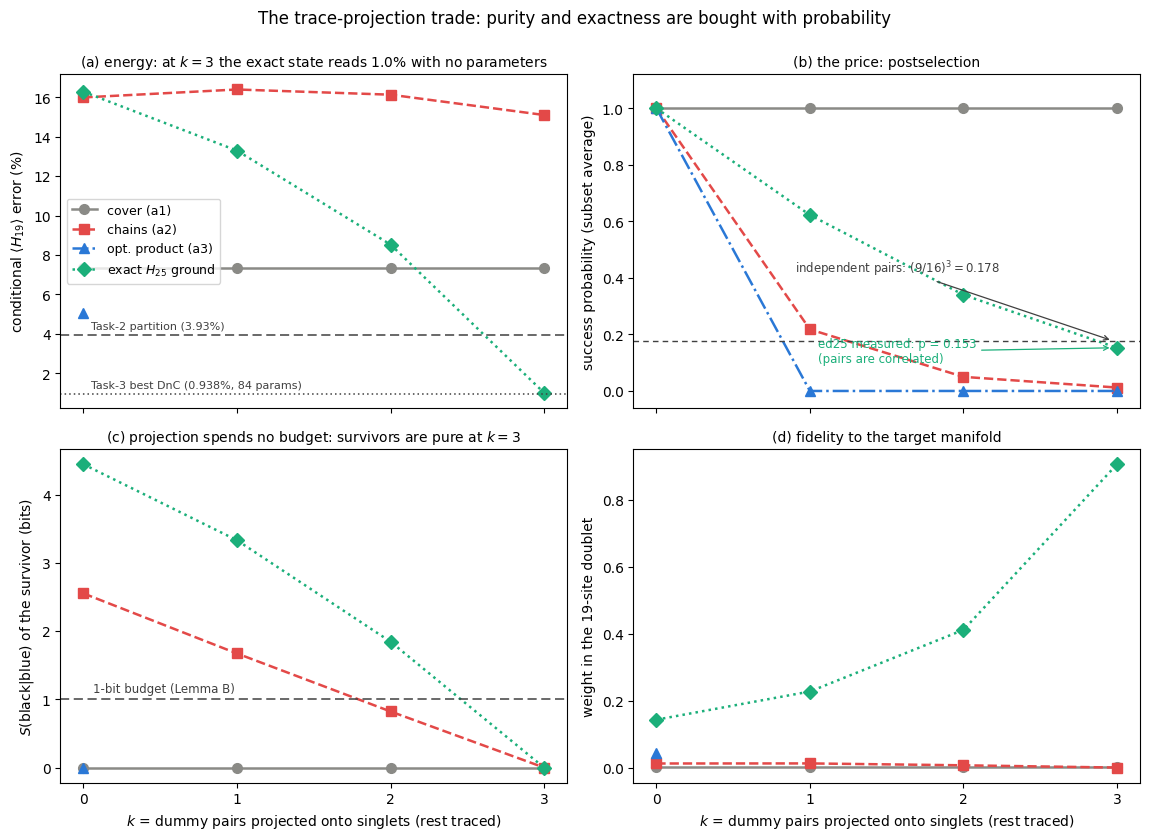

In [30]:
# --- Fig. 3 (CENTRAL): the trace-projection trade -------------------------------
# greyscale-safe: every state has its own marker AND linestyle as well as colour
STYLE = {"cover":       (GRAY,  "o", "-",   "cover (a1)"),
         "chains":      (RED,   "s", "--",  "chains (a2)"),
         "opt_product": (BLUE,  "^", "-.",  "opt. product (a3)"),
         "ed25":        (GREEN, "D", ":",   "exact $H_{25}$ ground")}
ks = np.arange(4)
fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.4), sharex=True)

for name in TRADE_STATES:
    c, mk, ls, lab = STYLE[name]
    axes[0, 0].plot(ks, [err(e) for e in curve(trades[name], "energy")],
                    marker=mk, ls=ls, color=c, label=lab, lw=1.8, ms=7)
    axes[0, 1].plot(ks, [pmean(trades[name], k) for k in ks],
                    marker=mk, ls=ls, color=c, lw=1.8, ms=7)
    axes[1, 0].plot(ks, curve(trades[name], "entropy"), marker=mk, ls=ls,
                    color=c, lw=1.8, ms=7)
    axes[1, 1].plot(ks, curve(trades[name], "doublet_weight"), marker=mk,
                    ls=ls, color=c, lw=1.8, ms=7)

ax = axes[0, 0]
ax.axhline(E_T2, color="#404040", lw=1.1, ls=(0, (6, 3)))
ax.text(0.05, E_T2 + 0.30, "Task-2 partition (3.93%)", fontsize=8,
        color="#404040", ha="left")
ax.axhline(E_T3, color="#404040", lw=1.1, ls=(0, (1, 2)))
ax.text(0.05, E_T3 + 0.30, "Task-3 best DnC (0.938%, 84 params)", fontsize=8,
        color="#404040", ha="left")
ax.set_ylabel(r"conditional $\langle H_{19}\rangle$ error (%)")
ax.legend(fontsize=9, loc="center left")
ax.set_title("(a) energy: at $k=3$ the exact state reads 1.0% with no "
             "parameters", fontsize=10)

ax = axes[0, 1]
ax.axhline((9 / 16) ** 3, color="#404040", lw=1.0, ls=(0, (4, 3)))
ax.annotate(r"independent pairs: $(9/16)^3 = 0.178$",
            xy=(2.97, (9 / 16) ** 3), xytext=(0.9, 0.42), fontsize=8.5,
            color="#404040",
            arrowprops=dict(arrowstyle="->", lw=0.9, color="#404040",
                            shrinkB=2))
ax.annotate(f"ed25 measured: p = {pmean(trades['ed25'], 3):.3f}\n"
            f"(pairs are correlated)",
            xy=(2.97, pmean(trades["ed25"], 3)), xytext=(1.05, 0.10),
            fontsize=8.5, color=GREEN,
            arrowprops=dict(arrowstyle="->", lw=0.9, color=GREEN, shrinkB=2))
ax.set_ylim(-0.06, 1.12)
ax.set_ylabel("success probability (subset average)")
ax.set_title("(b) the price: postselection", fontsize=10)

ax = axes[1, 0]
ax.axhline(1.0, color="#404040", lw=1.1, ls=(0, (6, 3)))
ax.text(0.06, 1.10, "1-bit budget (Lemma B)", color="#404040", fontsize=8.5)
ax.set_ylabel(r"$S(\mathrm{black}|\mathrm{blue})$ of the survivor (bits)")
ax.set_title("(c) projection spends no budget: survivors are pure at $k=3$",
             fontsize=10)

axes[1, 1].set_ylabel("weight in the 19-site doublet")
axes[1, 1].set_title("(d) fidelity to the target manifold", fontsize=10)
for ax in axes[1]:
    ax.set_xlabel(r"$k$ = dummy pairs projected onto singlets (rest traced)")
    ax.set_xticks(ks)
fig.suptitle("The trace-projection trade: purity and exactness are bought "
             "with probability", y=0.995, fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "fig3_trade_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Why one insertion beats another: the cut identity

§8 will show that all five embeddings are the *same lattice*, so the insertion choice is
a *readout* choice. What does a readout cost? At product level the answer is exact.

> **Proposition 8 (cut identity).** An insertion induces a bipartition of the 19 black
> sites into its two fragments. Let $C$ be the set of $H_{19}$ bonds joining them (all
> necessarily virtual). Then the product bound is
> $$a_3=E_0\big(H_{19}\setminus C\big)=E_{19}-\!\!\sum_{(ij)\in C}\!\!\langle h_{ij}
> \rangle_{g}\;+\;\Delta,\qquad \Delta\le 0,$$
> where $\langle h_{ij}\rangle_g$ are the target state's bond energies (multiplet
> invariants, since $h_{ij}$ is an SU(2) scalar, verified to $2\times10^{-13}$ across
> the doublet) and $\Delta$ is what re-optimizing the two disconnected pieces wins back.
> Verified to machine zero for all five insertions.

So the design question is *which bonds a readout cuts*. The natural guess — "insert where
the bonds that become virtual are energetically cheap" — is **refuted** at per-bond
resolution: the mean crossing-bond energy is $-0.783$ for the winning insertions and
$-0.794$ for the canonical one, i.e. equal to 1.4%. What actually differs is the
*number* of crossing bonds, 4 versus 6:

> **Design rule (measured).** Minimize $\sum_{C}\langle h_{ij}\rangle_g$, the *total*
> target-state energy crossing the induced cut. Here that total is dominated by
> $|C|$, not by bond selection: the shared-host geometry of §8 keeps one virtual bond
> *inside* the black fragment, so it never enters $C$.

Honest caveat, visible in Fig. 4(a): across the five points the rule is a
group-separation, not a monotone law. Within the 6-bond group the canonical insertion
sacrifices slightly *more* energy ($-4.766$ vs $-4.760$) yet lands slightly *better*
(5.08% vs 5.49%), because the re-optimization term $\Delta$ goes the other way. The rule
predicts the 8 $\times$ effect between groups, not the 0.4-point differences inside one.

In [31]:
# Prop. 8: bond price list, cut accounting, and the identity ---------------------
E_bond = kt.bond_energies19(V19[:, 0])
E_bond_alt = kt.bond_energies19(V19[:, 1])
dev = max(abs(E_bond[b] - E_bond_alt[b]) for b in kt.EDGES19)
print(f"bond energies are multiplet invariants: max deviation across the "
      f"doublet = {dev:.2e}")
assert dev < 1e-10
assert_close(sum(E_bond.values()), E19, 1e-9, "bond energies sum to E19")
vals = np.array(sorted(E_bond.values()))
print(f"the target's bond 'price list' ({len(vals)} bonds): min {vals[0]:.4f}, "
      f"max {vals[-1]:.4f}, mean {vals.mean():.4f}")
print(f"  distinct values: {np.unique(np.round(vals, 3))}")

print(f"\n{'triplet':>12s} {'|C|':>4s} {'sum_C':>8s} {'mean_C':>8s} "
      f"{'Delta':>8s} {'a3':>10s} {'err%':>7s} {'identity resid':>15s}")
cuts = {}
for trip in kt.SPLITTING_TRIPLETS:
    ins_t = kt.insert_dummies(trip)
    c = kt.cut_accounting(ins_t, E_bond, E19)
    r = kt.cut_identity_residual(ins_t)
    cuts[trip] = c
    print(f"{str(trip):>12s} {c['n_cross']:4d} {c['sum_cross']:8.4f} "
          f"{c['mean_cross']:8.4f} {c['defect']:8.4f} {c['a3']:10.4f} "
          f"{c['err_pct']:7.3f} {r:15.1e}")
    assert r < 1e-9, "cut identity broken"
means = np.array([abs(c["mean_cross"]) for c in cuts.values()])
print(f"\nmean crossing-bond energy |.| across insertions: {means.min():.4f} "
      f".. {means.max():.4f}  (spread "
      f"{100 * (means.max() / means.min() - 1):.1f}%)  -> the 'cheap bonds' "
      f"hypothesis is REFUTED: the insertions pay the same price PER BOND")
print(f"crossing-bond counts: "
      f"{ {t: c['n_cross'] for t, c in cuts.items()} }  -> the count is the "
      f"mechanism")
for trip in ((1, 10, 11), (2, 11, 12)):
    assert cuts[trip]["n_cross"] == 4 and cuts[trip]["err_pct"] < 0.7
assert cuts[kt.CANONICAL]["n_cross"] == 6

bond energies are multiplet invariants: max deviation across the doublet = 2.24e-13
the target's bond 'price list' (30 bonds): min -1.8778, max 0.0225, mean -0.9715
  distinct values: [-1.878 -1.604 -1.333 -1.296 -1.067 -0.793  0.014  0.023]

     triplet  |C|    sum_C   mean_C    Delta         a3    err%  identity resid
 (1, 10, 11)    4  -3.1332  -0.7833  -2.9344   -28.9474   0.682         0.0e+00
 (2, 11, 12)    4  -3.1332  -0.7833  -2.9344   -28.9474   0.682         0.0e+00
 (4, 11, 14)    6  -4.7601  -0.7934  -3.1607   -27.5468   5.487         0.0e+00
 (6, 11, 16)    6  -4.7659  -0.7943  -3.2847   -27.6650   5.082         0.0e+00
 (8, 11, 17)    6  -4.7601  -0.7934  -3.1607   -27.5468   5.487         0.0e+00

mean crossing-bond energy |.| across insertions: 0.7833 .. 0.7943  (spread 1.4%)  -> the 'cheap bonds' hypothesis is REFUTED: the insertions pay the same price PER BOND
crossing-bond counts: {(1, 10, 11): 4, (2, 11, 12): 4, (4, 11, 14): 6, (6, 11, 16): 6, (8, 11, 17): 6}  -> 

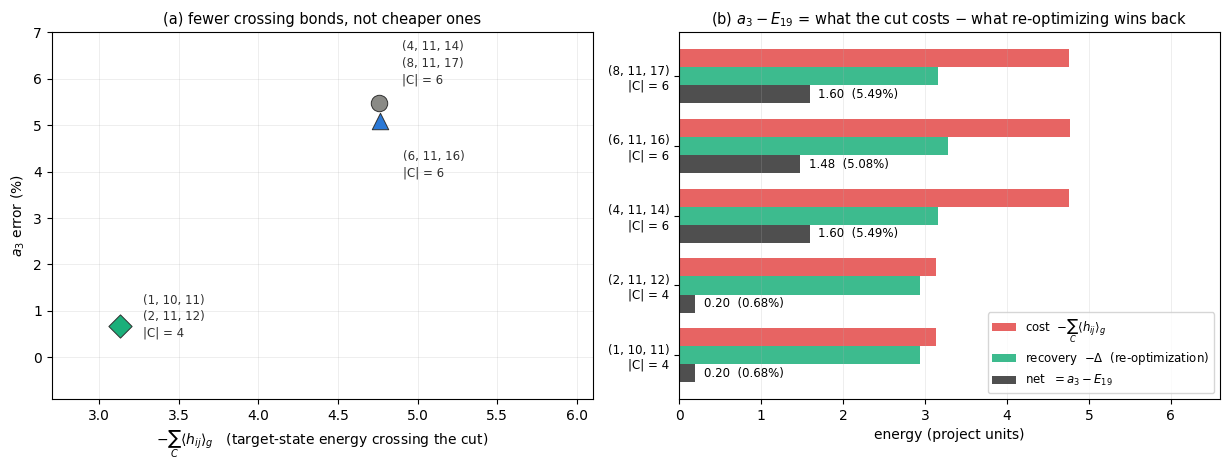

In [32]:
# --- Fig. 4: the cut mechanism ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))
trips = list(cuts)
COL = lambda t: (GREEN if cuts[t]["n_cross"] == 4
                 else (BLUE if t == kt.CANONICAL else GRAY))
MRK = lambda t: ("D" if cuts[t]["n_cross"] == 4
                 else ("^" if t == kt.CANONICAL else "o"))

# (a) price of the cut vs the product bound; identical points are grouped so
# that no two labels overlap
ax = axes[0]
groups = {}
for t in trips:
    key = (round(-cuts[t]["sum_cross"], 3), round(cuts[t]["err_pct"], 3))
    groups.setdefault(key, []).append(t)
# labels are stacked by y-rank so the two 6-bond clusters never collide
order = sorted(groups, key=lambda g: g[1])
DY = {0: -8, 1: -40, 2: 14}                     # low, middle, high
for rank, key in enumerate(order):
    x, y = key
    ts = groups[key]
    ax.scatter(x, y, s=140, color=COL(ts[0]), marker=MRK(ts[0]), zorder=5,
               edgecolor="#303030", linewidth=0.7)
    lab = "\n".join(str(t) for t in ts) + f"\n|C| = {cuts[ts[0]]['n_cross']}"
    ax.annotate(lab, (x, y), textcoords="offset points",
                xytext=(16, DY[rank]), fontsize=8.5, ha="left",
                linespacing=1.35, color="#303030")
ax.set_xlabel(r"$-\sum_{C}\langle h_{ij}\rangle_g$   "
              r"(target-state energy crossing the cut)")
ax.set_ylabel(r"$a_3$ error (%)")
ax.set_title("(a) fewer crossing bonds, not cheaper ones", fontsize=10.5)
ax.set_xlim(2.7, 6.1); ax.set_ylim(-0.9, 7.0)
ax.grid(alpha=0.25, lw=0.6)

# (b) the exact decomposition a3 - E19 = cost - recovery, as grouped bars
ax = axes[1]
cost = np.array([-cuts[t]["sum_cross"] for t in trips])
recov = np.array([-cuts[t]["defect"] for t in trips])
net = cost - recov
y0 = np.arange(len(trips)); h = 0.26
ax.barh(y0 + h, cost, height=h, color=RED, alpha=0.85,
        label=r"cost  $-\sum_C \langle h_{ij}\rangle_g$")
ax.barh(y0, recov, height=h, color=GREEN, alpha=0.85,
        label=r"recovery  $-\Delta$  (re-optimization)")
ax.barh(y0 - h, net, height=h, color="#303030", alpha=0.85,
        label=r"net  $= a_3 - E_{19}$")
for i, t in enumerate(trips):
    ax.text(net[i] + 0.10, i - h, f"{net[i]:.2f}  ({cuts[t]['err_pct']:.2f}%)",
            va="center", fontsize=8.5)
ax.set_yticks(y0, [f"{t}\n|C| = {cuts[t]['n_cross']}" for t in trips],
              fontsize=8.5)
ax.set_xlabel("energy (project units)")
ax.set_title(r"(b) $a_3 - E_{19}$ = what the cut costs $-$ what "
             r"re-optimizing wins back", fontsize=10.5)
ax.legend(fontsize=8.5, loc="lower right")
ax.set_xlim(0, 6.6)
ax.grid(alpha=0.25, lw=0.6, axis="x")
fig.tight_layout()
fig.savefig(FIGURES / "fig4_cut_mechanism.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. One lattice, five readouts — and does the advantage survive?

> **Proposition 7.** The five admissible embeddings are *pairwise graph-isomorphic*
> (verified below). $H_{25}$ therefore has the *same spectrum* in all five cases , the
> enlarged problem is literally one problem. What the insertion choice selects is not a
> Hamiltonian but a *readout*: which 19 of the 25 qubits are called black.

That makes the comparison a controlled experiment: the *same* physical state, read two
ways. The exact ground state of the shared-host embedding $(2,11,12)$ was computed
independently (same 8-min pipeline, `results/ed25_2_11_12.npz`) and confirms the
spectrum to $10^{-6}$.

**Does the 7 $\times$ depth-0 advantage survive to the exact state? No.**

| reading of the exact $H_{25}$ ground state | canonical $(6,11,16)$ | shared-host $(2,11,12)$ |
|---|---|---|
| product bound $a_3$ (depth 0) | 5.082% | 0.682%  (7.5$\times$ better) |
| trace, $k=0$ | 16.28%, 4.45 bits | 13.48%, 4.04 bits (1.2 $\times$) |
| projection, $k=3$ | 1.015%, $w=0.907$, $p=0.153$ | 1.024%, $w=0.903$, $p=0.154$ (equal) |

The reading is clean. The cut advantage is a *product-state* effect: it says the
shared-host bipartition is a better divide-and-conquer partition *of the original
19-site problem* and that stands on its own, independent of any dummy (0.682% with
zero variational parameters, against Task-2's 3.93%). It does **not** make the dummy
embedding a better spin-liquid generator: once the state is exact, the trace advantage
shrinks to 1.2 $\times$ and the projected reading is readout-independent to the third
digit, as befits the intrinsic, SU(2)-equivariant contraction of Theorem P. Note the
two dummy-pair sets are *not* related by the isomorphism, so this coincidence is
measured robustness, not a symmetry identity.

In [33]:
# Prop. 7 + the controlled comparison ---------------------------------------------
Gs = {t: nx.Graph(kt.insert_dummies(t).edges) for t in kt.SPLITTING_TRIPLETS}
iso = {t: nx.is_isomorphic(G, Gs[kt.CANONICAL]) for t, G in Gs.items()}
print("graph isomorphism of the five 25-site lattices:", iso)
assert all(iso.values())
GM = nx.algorithms.isomorphism.GraphMatcher(Gs[(2, 11, 12)], Gs[kt.CANONICAL])
assert GM.is_isomorphic()
mp = GM.mapping
alt_pairs_img = {tuple(sorted((mp[a], mp[b])))
                 for a, b in kt.insert_dummies((2, 11, 12)).pairs}
can_pairs = {tuple(sorted(p)) for p in ins.pairs}
print(f"under one explicit isomorphism the alt dummy pairs map to "
      f"{sorted(alt_pairs_img)},")
print(f"  vs the canonical pairs {sorted(can_pairs)} -> "
      f"identical set: {alt_pairs_img == can_pairs}")

alt_path = RESULTS / "ed25_2_11_12.npz"
if alt_path.exists():
    dA = np.load(alt_path)
    print(f"\nalt ed25: E0 = {float(dA['E0']):.6f} vs canonical {E25:.6f}  "
          f"(difference {abs(float(dA['E0']) - E25):.2e}), <S2> = "
          f"{float(dA['s2'][0]):.6f}")
    assert abs(float(dA["E0"]) - E25) < 1e-6
    trades["ed25_alt"] = kt.load_trade(RESULTS / "trade_ed25_2_11_12.npz")
    print(f"\n{'reading':16s} {'canonical (6,11,16)':>22s} "
          f"{'shared-host (2,11,12)':>24s}")
    print(f"{'a3 (depth 0)':16s} {cuts[kt.CANONICAL]['err_pct']:21.3f}% "
          f"{cuts[(2, 11, 12)]['err_pct']:23.3f}%")
    for k, lab in ((0, "trace  (k=0)"), (3, "project (k=3)")):
        ec, ea = (err(curve(trades["ed25"], "energy")[k]),
                  err(curve(trades["ed25_alt"], "energy")[k]))
        sc, sa = (curve(trades["ed25"], "entropy")[k],
                  curve(trades["ed25_alt"], "entropy")[k])
        wc, wa = (curve(trades["ed25"], "doublet_weight")[k],
                  curve(trades["ed25_alt"], "doublet_weight")[k])
        print(f"{lab:16s} {ec:15.3f}% S={sc:4.2f} w={wc:4.2f} "
              f"{ea:17.3f}% S={sa:4.2f} w={wa:4.2f}")
    surv = (err(curve(trades["ed25_alt"], "energy")[0])
            / err(curve(trades["ed25"], "energy")[0]))
    print(f"\ndepth-0 advantage {cuts[kt.CANONICAL]['err_pct'] / cuts[(2, 11, 12)]['err_pct']:.1f}x "
          f"-> trace advantage {1 / surv:.2f}x -> projection advantage "
          f"{err(curve(trades['ed25'], 'energy')[3]) / err(curve(trades['ed25_alt'], 'energy')[3]):.2f}x "
          f"(none)")
else:
    print("\nalt ed25 artifact absent; run the companion script to reproduce")

graph isomorphism of the five 25-site lattices: {(1, 10, 11): True, (2, 11, 12): True, (4, 11, 14): True, (6, 11, 16): True, (8, 11, 17): True}
under one explicit isomorphism the alt dummy pairs map to [(2, 3), (13, 14), (21, 22)],
  vs the canonical pairs [(19, 20), (21, 22), (23, 24)] -> identical set: False

alt ed25: E0 = -38.140287 vs canonical -38.140287  (difference 1.35e-13), <S2> = 0.750000

reading             canonical (6,11,16)    shared-host (2,11,12)
a3 (depth 0)                     5.082%                   0.682%
trace  (k=0)              16.277% S=4.45 w=0.14            13.479% S=4.04 w=0.16
project (k=3)              1.015% S=0.00 w=0.91             1.024% S=0.00 w=0.90

depth-0 advantage 7.5x -> trace advantage 1.21x -> projection advantage 0.99x (none)


## 9. Head-to-head: dummies as preparation ancillas, at equal parameters

§2 showed the gain cannot come from state structure at depth 0, and Lemma B caps what the
trace can ever deliver. The well-posed variational question is:

> *At equal parameter budget, does the 25-qubit ansatz with dummy triangles reach a
> better black energy than the 19-qubit ansatz alone?*

**Design.** 25q side: start from a depth-0 product, apply `reps` layers of SU(2)
Heisenberg gates on the 9 blue-triangle bonds (Ahsan's "transfer dimers", made
variational), objective $\langle H_{19}\rangle$; `dc.RecombinationVQE` reused verbatim
with `edges_full = EDGES19`, `interface_edges = ins.dummy_edges`. 19q side: the Task-1
HVA reference curves, which start from the same $-27$ floor.

**Stationarity, measured.** Both starts are products of $S^2$-pure blocks, so the Task-3
stationarity theorem predicts $\|\nabla E\|=0$ at $\theta=0$ against any SU(2) junction
gate, measured *exactly 0*. All escapes are by random init.

**Outcome: a negative result with a localized mechanism.** The junction cannot leave the
product floor. From the cover start L-BFGS returns to $-27.0000$ *exactly* at 9 and 18
parameters, and the Task-3 remedy does not rescue it: a *wide* junction (gates also on
the six black bonds incident to the corners, 15 bonds/layer, 30 parameters — directly
comparable to both 19q references) lands on the same floor after 55 iterations. From the
exact-chain start the gates do help ($-24.4858\to-25.7635$) but never reach even $-27$.
At 30 parameters the plain 19q HVA sits at 3.98%. *As junction ancillas the dummies lose
outright*, entangling the corners with the dummies costs the corner dimers more than the
virtual bonds return, everywhere the optimizer can reach.

*No further 25q VQE runs are reported: the stationarity theorem already explains the
plateau, and the contribution of this task is the duality, not a better VQE number.*


In [34]:
# head-to-head: auto-load VQE runs + Task-1 references ---------------------------
ref_full = np.load(HERE.parent / "1_Task/results/res19_full.npz")["meta"]
ref_sym  = np.load(HERE.parent / "1_Task/results/res19_sym.npz")["meta"]
print("19q reference (res19_full):  params", ref_full[:, 1].astype(int).tolist(),
      " err%", np.round(ref_full[:, 3], 3).tolist())
print("19q reference (res19_sym) :  params", ref_sym[:, 1].astype(int).tolist(),
      " err%", np.round(ref_sym[:, 3], 3).tolist())

vqe0 = dc.RecombinationVQE(psi_cover, n=25, edges_full=kt.EDGES19,
                           interface_edges=ins.dummy_edges,
                           h_sel_edges=ins.dummy_edges)
E0z, g0 = vqe0.gradient_at_zero(reps=1)
print(f"\nTask-3 stationarity at 25 qubits (cover start, 9 junction params): "
      f"E = {E0z:.4f}, |grad| = {g0:.3e}")
assert g0 < 1e-12

vqe_runs = []
for f_ in sorted(RESULTS.glob("vqe25_junction_*.npz")):
    tag = f_.stem.replace("vqe25_junction_", "")
    for r in dc.load_runs(f_):
        r["tag"], r["start"] = tag, tag.split("_")[0]
        vqe_runs.append(r)
print(f"\n{'tag':>10s} {'start':>7s} {'seed':>4s} {'params':>6s} {'<H19>':>9s} "
      f"{'err%':>7s} {'iters':>5s} {'time':>7s}")
for r in sorted(vqe_runs, key=lambda r: (r["n_params"], r["seed"])):
    print(f"{r['tag']:>10s} {r['start']:>7s} {r['seed']:4d} {r['n_params']:6d} "
          f"{r['energy']:9.4f} {r['err_pct']:7.3f} {r['nit']:5d} "
          f"{r['time_s']:6.0f}s")
best_vqe = min(vqe_runs, key=lambda r: r["energy"])
sym_ref = {int(p): e for p, e in zip(ref_sym[:, 1], ref_sym[:, 3])}
print(f"\nbest 25q junction: {best_vqe['energy']:.4f} "
      f"({best_vqe['err_pct']:.3f}%) at {best_vqe['n_params']} params;  "
      f"19q HVA at 30 params: {sym_ref[30]:.3f}%")
assert all(r["energy"] >= -27.0 - 1e-9 for r in vqe_runs if r["start"] != "chains")

19q reference (res19_full):  params [0, 30, 60, 90, 120]  err% [7.363, 5.534, 3.138, 2.945, 0.802]
19q reference (res19_sym) :  params [0, 5, 10, 15, 20, 25, 30]  err% [7.363, 7.363, 5.064, 4.564, 4.263, 4.106, 3.976]

Task-3 stationarity at 25 qubits (cover start, 9 junction params): E = -27.0000, |grad| = 0.000e+00

       tag   start seed params     <H19>    err% iters    time
  cover_r1   cover    0      9  -27.0000   7.363    14   1411s
  cover_r1   cover    1      9  -27.0000   7.363    16   1224s
 chains_r2  chains    0     18  -25.7635  11.606    20   2012s
  cover_r2   cover    0     18  -27.0000   7.363    10   1131s
   wide_r2    wide    0     30  -27.0000   7.363    55   7110s

best 25q junction: -27.0000 (7.363%) at 9 params;  19q HVA at 30 params: 3.976%


In [35]:
# both readings of the best VQE state --------------------------------------------
trade_vqe_path = RESULTS / "trade_vqe_best.npz"
if trade_vqe_path.exists() and not RECOMPUTE_HEAVY:
    trades["vqe_best"] = kt.load_trade(trade_vqe_path)
else:
    start_psi = (psi_cover if best_vqe["start"] == "cover" else
                 kt.embed_fragments(ins, a2["psi_black"], a2["psi_mixed"]))
    vqe = dc.RecombinationVQE(start_psi, n=25, edges_full=kt.EDGES19,
                              interface_edges=ins.dummy_edges,
                              h_sel_edges=ins.dummy_edges)
    sched, npar = vqe.schedule(best_vqe["reps"], per_bond=best_vqe["per_bond"])
    sv = vqe.statevector(np.asarray(best_vqe["x"]), sched)
    assert_close(vqe.energy(sv), best_vqe["energy"], 1e-6, "replayed VQE state")
    trades["vqe_best"] = kt.trade_curve(sv, V19=V19, ins=ins)
    kt.save_trade(trades["vqe_best"], trade_vqe_path)
e_k = curve(trades["vqe_best"], "energy")
print(f"best VQE state: trace {e_k[0]:.4f} ({err(e_k[0]):.3f}%);  k=3 "
      f"projection {e_k[3]:.4f} ({err(e_k[3]):.3f}%) at p = "
      f"{pmean(trades['vqe_best'], 3):.4f}")

best VQE state: trace -27.0000 (7.363%);  k=3 projection -27.0000 (7.363%) at p = 1.0000


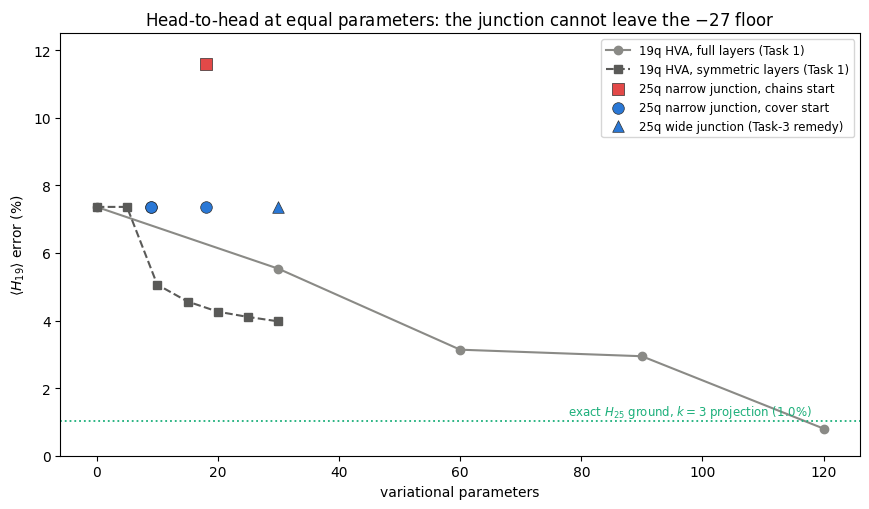

In [36]:
# --- Fig. 5: error vs parameter budget ------------------------------------------
fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.plot(ref_full[:, 1], ref_full[:, 3], marker="o", ls="-", color=GRAY,
        label="19q HVA, full layers (Task 1)")
ax.plot(ref_sym[:, 1], ref_sym[:, 3], marker="s", ls="--", color="#5a5a58",
        label="19q HVA, symmetric layers (Task 1)")
VS = {"cover": (BLUE, "o", "25q narrow junction, cover start"),
      "chains": (RED, "s", "25q narrow junction, chains start"),
      "wide": (BLUE, "^", "25q wide junction (Task-3 remedy)")}
seen = set()
for r in vqe_runs:
    c, mk, lab = VS.get(r["start"], (GRAY, "x", "other"))
    ax.scatter(r["n_params"], r["err_pct"], color=c, marker=mk, s=70, zorder=5,
               edgecolor="#303030", linewidth=0.5,
               label=lab if lab not in seen else None)
    seen.add(lab)
ax.axhline(err(curve(trades["ed25"], "energy")[3]), color=GREEN, lw=1.3,
           ls=":")
ax.text(118, err(curve(trades["ed25"], "energy")[3]) + 0.18,
        r"exact $H_{25}$ ground, $k{=}3$ projection (1.0%)", color=GREEN,
        fontsize=8.5, ha="right")
ax.set_xlabel("variational parameters")
ax.set_ylabel(r"$\langle H_{19}\rangle$ error (%)")
ax.set_title("Head-to-head at equal parameters: the junction cannot leave the "
             "$-27$ floor")
ax.legend(fontsize=8.5)
ax.set_ylim(0, 12.5)
fig.tight_layout()
fig.savefig(FIGURES / "fig5_head_to_head.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. The open path, and why the obvious program is the wrong one

§6 leaves an asymmetry: the projected reading of the **exact** $H_{25}$ ground state is
excellent, but "exact" is not a preparation recipe. Is there a *variational* 25-qubit
path whose projection is good? Two exact statements first, then the measured program.

> **Lemma J (junction inertness under projection).** Let the start state have, in each
> dummy triangle $(c,\,\text{apex},\,\text{copy})$, two of the three legs in a mutual
> singlet, and let $U$ be any SU(2)-preserving circuit supported on the blue
> triangles. Then the $k=3$ survivor is invariant,
> $$\langle s|^{\otimes 3}\,U\,|\Psi_0\rangle=\Big(\prod_\triangle
> \lambda_\triangle(U)\Big)\;\langle s|^{\otimes 3}|\Psi_0\rangle ,$$
> and only the success probability changes, by $\prod_\triangle|\lambda_\triangle|^2$.
>
> *Proof.* The singlet reduces each triangle's free content to a single spin-$\frac12$;
> the contracted circuit is then an SU(2)-equivariant map $\frac12\to\frac12$, and
> $\mathrm{Hom}_{SU(2)}(\frac12,\frac12)$ is one-dimensional (Schur), so it is a scalar
> multiple of the reference map. $\square$
>
> For a single Heisenberg gate on (corner, apex) the scalar is
> $|\lambda|^2=(5+3\cos\theta)/8$; gates *within* one triangle do not commute, so a
> general circuit needs the full triangle contraction (`kt.lemma_j_check`), while
> different triangles always factorize.
>
> **Consequence.** From the cover start (apex-copy singlets) *or* the swap start
> (corner-apex singlets), the whole junction orbit is *dead* in the projected reading:
> it cannot change the survivor, only make it rarer. §9's measured negative result is,
> on this side of the duality, a theorem.

> **The swap identity.** The entanglement-swap state — singlets on (corner, apex), the
> exact mixed-chain ground carrying the primed copies, and the remaining 8 black sites
> in the ground state of their induced $H_{19}$ graph — projects with $p=1/64$
> *exactly* (three swaps of amplitude $-\tfrac12$) onto [the chain *teleported onto
> the black lattice*, with the six virtual bonds now active] $\otimes$ [8-site ground]:
> $$E_{\rm proj}=-15-12.665016=a_3\quad\text{exactly.}$$
> The two bipartitions are mirror images, so the purest form of "transfer dimers to the
> black triangles" — teleporting *exact fragments* through the dummies — reproduces the
> product bound and never beats it. Teleportation relocates where the energy lives; it
> does not create any.

**The plateau covers both objectives.** At $\theta=0$, for all three product starts,
$\|\nabla\langle H_{25}\rangle\|=0$ *and* $\|\nabla E_{\rm proj}\|=0$: Task-3
stationarity extends both to the enlarged objective and to the conditional projected
energy. Escapes are by random init, exactly as in Task 3, which from equally stationary
starts reached 0.938%.

**The obvious program, and its refutation.** The natural remaining move is the advisor's
own panel-(d) objective read the other way: minimize $\langle H_{25}\rangle$ (real
bonds, adjoint gradients, no virtual operators) from the Theorem-5 exact-fragment start,
and project once at the end. It was run (three configurations, 5 h 38 min; table below)
and it is *the wrong objective*, provably:

> **Proposition 9 (misalignment).** Let $|\Psi_\perp\rangle=|g_{19}\rangle\otimes
> |s\rangle^{\otimes3}$, the 19-site ground state times singlets *on the dummy pairs
> themselves*. Its $k=3$ projection returns $|g_{19}\rangle$ *exactly, with $p=1$* — the
> Bell bra hits its own singlet — so $E_{\rm proj}=E_{19}$ (0.000%) and, being pure and
> factorized, the traced reading is 0.000% too, at zero bits (the Lemma-B corollary made
> concrete). Yet $\langle H_{25}\rangle=-33.3803$, a 12.48% error on the enlarged
> problem. Meanwhile the exact $H_{25}$ ground state, 0.00% on the enlarged problem,
> reads 1.015% projected. The two objectives are therefore not merely different but
> *anti-ordered on this pair of states*: driving $\langle H_{25}\rangle\to E_{25}$
> moves *away* from the best black readout.

> **Corollary (no free lunch).** The $k=3$ projection is onto: every 19-qubit state is
> the survivor of some 25-qubit state (namely $|\varphi\rangle\otimes|s\rangle^{\otimes3}$,
> at $p=1$). Hence $\min_\Psi E_{\rm proj}(\Psi)=E_{19}$ exactly; the projected problem
> has the same optimum as the original one, and its trivial minimizer already *contains*
> the answer. The dummy qubits add parameters, never reachability.

**What is actually still open**, stated as narrowly as the evidence allows: not the
global optimum (fixed by the corollary), and not the junction family (closed by Lemma J
and the head-to-head), but whether a general shallow 25-qubit ansatz (free to
entangle black and dummy qubits, scored directly on $E_{\rm proj}$) reaches a better
black energy *at fixed circuit depth* than the same-depth 19-qubit ansatz. That is the
ordinary "ancillas buy expressivity" question, and it is the only door this task leaves
open. Fig. 6 shows why the door is narrow: the states measured here scatter, and the
misalignment point sits far off any monotone transfer curve.

In [37]:
# Lemma J, the swap identity, and the plateau table (auto-loaded probes) --------
pr_path = RESULTS / "open_path_probes.npz"
assert pr_path.exists(), "run the persist_probes companion script first"
pr = dict(np.load(pr_path))
g = lambda k: float(pr[k])

print("Lemma J at 25 qubits (random 9-gate junction circuit on the cover):")
print(f"  survivor fidelity vs the un-rotated survivor = {g('lemma_fid'):.12f}")
print(f"  p measured = {g('lemma_p_meas'):.6f}   vs  prod |lambda_tri|^2 = "
      f"{g('lemma_p_pred'):.6f}   (ratio "
      f"{g('lemma_p_meas') / g('lemma_p_pred'):.9f})")
assert g("lemma_fid") > 1 - 1e-9
assert abs(g("lemma_p_meas") / g("lemma_p_pred") - 1) < 1e-6

lam1, res1 = kt.lemma_j_check([(("c", "a"), 0.7)], mode="pair")
assert res1 < 1e-12 and abs(abs(lam1) ** 2 - (5 + 3 * np.cos(0.7)) / 8) < 1e-12
lam5, res5 = kt.lemma_j_check([(("c", "a"), 0.5), (("a", "p"), -0.9),
                               (("c", "p"), 1.1), (("c", "a"), -0.3),
                               (("c", "p"), 0.8)], mode="pair")
lam_s, res_s = kt.lemma_j_check([], mode="swap")
assert res5 < 1e-12 and res_s < 1e-12 and abs(lam_s + 0.5) < 1e-12
print(f"  Schur scalars: one-gate closed form (5+3cos)/8 exact to "
      f"{abs(abs(lam1) ** 2 - (5 + 3 * np.cos(0.7)) / 8):.1e};  a 5-gate "
      f"non-commuting circuit is still a scalar (residual {res5:.1e});")
print(f"  swap-mode lambda at U = 1 is {lam_s.real:+.3f}, so three swaps give "
      f"p = (1/2)^6 = 1/64")

print(f"\nswap identity: E_proj = {g('swap_e3'):.6f}  vs  a3 = "
      f"{a3['energy']:.6f}   (difference "
      f"{abs(g('swap_e3') - a3['energy']):.1e})")
print(f"  p = {g('swap_p3'):.6f} = 1/64 = {1 / 64:.6f};  doublet weight "
      f"{g('swap_w3'):.4f};  traced reading of the same state: "
      f"{g('swap_trace_e'):.4f} ({err(g('swap_trace_e')):.3f}%, "
      f"S = {g('swap_trace_S'):.4f} bits)")
assert abs(g("swap_e3") - a3["energy"]) < 1e-6
assert abs(g("swap_p3") - 1 / 64) < 1e-9

print(f"\nthe stationarity plateau covers BOTH objectives (theta = 0):")
print(f"{'start':8s} {'<H25>':>9s} {'|grad H25|':>11s} {'E_proj':>9s} "
      f"{'p':>8s} {'|grad E_proj|':>14s}")
for nm in ("cover", "chains", "swap"):
    print(f"{nm:8s} {g('h25_' + nm):9.4f} {g('grad_h25_' + nm):11.2e} "
          f"{g('eproj_' + nm):9.4f} {g('p3_' + nm):8.4f} "
          f"{g('grad_eproj_' + nm):14.2e}")
    assert g("grad_h25_" + nm) < 1e-10 and g("grad_eproj_" + nm) < 1e-6

Lemma J at 25 qubits (random 9-gate junction circuit on the cover):
  survivor fidelity vs the un-rotated survivor = 1.000000000000
  p measured = 0.449688   vs  prod |lambda_tri|^2 = 0.449688   (ratio 1.000000000)
  Schur scalars: one-gate closed form (5+3cos)/8 exact to 3.3e-16;  a 5-gate non-commuting circuit is still a scalar (residual 0.0e+00);
  swap-mode lambda at U = 1 is -0.500, so three swaps give p = (1/2)^6 = 1/64

swap identity: E_proj = -27.665016  vs  a3 = -27.665016   (difference 1.8e-14)
  p = 0.015625 = 1/64 = 0.015625;  doublet weight 0.0699;  traced reading of the same state: -20.4570 (29.812%, S = 5.8062 bits)

the stationarity plateau covers BOTH objectives (theta = 0):
start        <H25>  |grad H25|    E_proj        p  |grad E_proj|
cover     -36.0000    0.00e+00  -27.0000   1.0000       0.00e+00
chains    -28.7083    5.67e-16  -24.7455   0.0121       7.84e-11
swap      -36.6650    0.00e+00  -27.6650   0.0156       0.00e+00


Prop. 9 counterexample |g19> x |s>^3:
  <H25> = -33.380308  ->  12.480% on the ENLARGED problem
  k=3 projection: p = 1.000000, E_proj = -29.146168 -> 0.0000%, doublet weight 1.000000
  traced reading: -29.146168 (0.0000%) at S = 0.0000 bits (Lemma-B corollary: pure + exact => dummies inert)

       tag seed params     <H25>  err25% iters    time
 narrow_r1    0      9  -28.7083  24.730    42   3757s
 narrow_r1    1      9  -28.7083  24.730    29   1925s
 narrow_r2    0     18  -28.7083  24.730    77   8246s
   wide_r1    0     15  -29.9185  21.557    88   7516s

both readings of the best state per tag:
  VQE narrow_r1   : <H25> =  -28.7083 (24.730%)  ->  E_proj =  -24.7455 (15.099%)  at p = 0.0121
  VQE narrow_r2   : <H25> =  -28.7083 (24.730%)  ->  E_proj =  -24.7455 (15.099%)  at p = 0.0121
  VQE wide_r1     : <H25> =  -29.9185 (21.557%)  ->  E_proj =  -24.9298 (14.466%)  at p = 0.0121


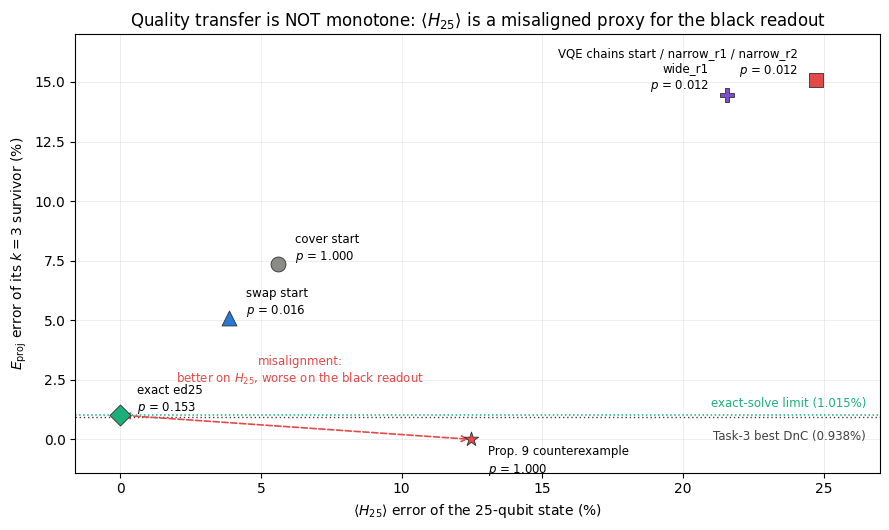

In [38]:
# the <H25> program: runs, both readings, and Fig. 6 -----------------------------
E25err = lambda E: 100.0 * abs(E - E25) / abs(E25)
h25_runs = []
for f_ in sorted(RESULTS.glob("vqe25_h25_*.npz")):
    tag = f_.stem.replace("vqe25_h25_", "")
    for r in dc.load_runs(f_):
        r["tag"] = tag
        h25_runs.append(r)

# Prop. 9: the misalignment counterexample, built and measured here
psi_perp = kt.decoupled_state(ins, V19[:, 0])
T_ = psi_perp.reshape((2,) * 25)
h25_perp = float(sum(np.real(dc.bond_vdot(25, T_, T_, kt._BOND, a_, b_))
                     for a_, b_ in ins.edges))
pt_perp = kt.trade_point(psi_perp, (0, 1, 2), ins.pairs, V19=V19)
m_perp = kt.black_moments(psi_perp, 25, V19=V19)
print(f"Prop. 9 counterexample |g19> x |s>^3:")
print(f"  <H25> = {h25_perp:.6f}  ->  {100 * abs(h25_perp - E25) / abs(E25):.3f}% "
      f"on the ENLARGED problem")
print(f"  k=3 projection: p = {pt_perp['prob']:.6f}, E_proj = "
      f"{pt_perp['energy']:.6f} -> {err(pt_perp['energy']):.4f}%, "
      f"doublet weight {pt_perp['doublet_weight']:.6f}")
print(f"  traced reading: {m_perp['energy']:.6f} ({err(m_perp['energy']):.4f}%) "
      f"at S = {m_perp['entropy']:.4f} bits (Lemma-B corollary: pure + exact "
      f"=> dummies inert)")
assert abs(pt_perp["prob"] - 1.0) < 1e-9
assert abs(pt_perp["energy"] - E19) < 1e-6
assert abs(h25_perp - E25) / abs(E25) > 0.10
del psi_perp, T_
print()

points = [("cover start", g("h25_cover"), g("eproj_cover"), g("p3_cover")),
          ("chains start", g("h25_chains"), g("eproj_chains"), g("p3_chains")),
          ("swap start", g("swap_h25"), g("swap_e3"), g("swap_p3")),
          ("exact ed25", E25, curve(trades["ed25"], "energy")[3],
           pmean(trades["ed25"], 3)),
          ("Prop. 9 counterexample", h25_perp, pt_perp["energy"],
           pt_perp["prob"])]

if h25_runs:
    print(f"{'tag':>10s} {'seed':>4s} {'params':>6s} {'<H25>':>9s} "
          f"{'err25%':>7s} {'iters':>5s} {'time':>7s}")
    for r in sorted(h25_runs, key=lambda r: (r["tag"], r["seed"])):
        print(f"{r['tag']:>10s} {r['seed']:4d} {r['n_params']:6d} "
              f"{r['energy']:9.4f} {E25err(r['energy']):7.3f} {r['nit']:5d} "
              f"{r['time_s']:6.0f}s")
    readings_path = RESULTS / "h25_readings.npz"
    if readings_path.exists() and not RECOMPUTE_HEAVY:
        d_ = np.load(readings_path, allow_pickle=True)
        vqe_pts = [(str(a), float(b), float(c_), float(dd))
                   for a, b, c_, dd in d_["pts"]]
    else:
        psi_ch = kt.embed_fragments(ins, a2["psi_black"], a2["psi_mixed"])
        corner_blk = [e for e in ins.edges
                      if (e[0] in ins.triplet or e[1] in ins.triplet)
                      and e[0] <= 18 and e[1] <= 18]
        best_by_tag = {}
        for r in h25_runs:
            if (r["tag"] not in best_by_tag
                    or r["energy"] < best_by_tag[r["tag"]]["energy"]):
                best_by_tag[r["tag"]] = r
        vqe_pts = []
        for tag, r in sorted(best_by_tag.items()):
            gates = (ins.dummy_edges if tag.startswith("narrow")
                     else sorted(set(ins.dummy_edges) | set(corner_blk)))
            v_ = dc.RecombinationVQE(psi_ch, n=25, edges_full=ins.edges,
                                     interface_edges=gates, h_sel_edges=gates)
            sch_, _ = v_.schedule(r["reps"], per_bond=r["per_bond"])
            sv_ = v_.statevector(np.asarray(r["x"]), sch_)
            assert abs(v_.energy(sv_) - r["energy"]) < 1e-6
            pt_ = kt.trade_point(sv_, (0, 1, 2), ins.pairs, V19=V19)
            vqe_pts.append((f"VQE {tag}", float(r["energy"]),
                            float(pt_["energy"]), float(pt_["prob"])))
            del sv_
        np.savez(readings_path, pts=np.array(vqe_pts, dtype=object))
    points += vqe_pts
    print("\nboth readings of the best state per tag:")
    for lab, h_, e_, p_ in vqe_pts:
        print(f"  {lab:16s}: <H25> = {h_:9.4f} ({E25err(h_):6.3f}%)  ->  "
              f"E_proj = {e_:9.4f} ({err(e_):6.3f}%)  at p = {p_:.4f}")
else:
    print("<H25> program: PENDING (queue still running) -- re-run this cell "
          "when results/vqe25_h25_*.npz exist")

fig, ax = plt.subplots(figsize=(9.0, 5.4))
MK = {"cover start": (GRAY, "o"), "chains start": (RED, "s"),
      "swap start": (BLUE, "^"), "exact ed25": (GREEN, "D"),
      "Prop. 9 counterexample": (RED, "*")}
groups7 = {}
for lab, h_, e_, p_ in points:                 # merge coincident points
    groups7.setdefault((round(E25err(h_), 2), round(err(e_), 2)),
                       []).append((lab, p_))
for (x_, y_), labs in groups7.items():
    lab0 = labs[0][0]
    c_, mk = MK.get(lab0, ("#7a4fc9", "P"))
    ax.scatter(x_, y_, s=115, color=c_, marker=mk, zorder=5,
               edgecolor="#303030", linewidth=0.6)
    name = " / ".join(l.replace("VQE ", "") for l, _ in labs)
    if len(labs) > 1:
        name = "VQE " + name
    dx, dy, ha = ((-13, 4, "right") if x_ > 18 else (12, 3, "left"))
    if y_ < 1.5 and x_ > 5:                 # clear of the two rules
        dy = -24
    ax.annotate(f"{name}\n$p$ = {labs[0][1]:.3f}", (x_, y_),
                textcoords="offset points", xytext=(dx, dy), fontsize=8.5,
                linespacing=1.3, ha=ha)
ax.axhline(err(curve(trades["ed25"], "energy")[3]), color=GREEN, lw=1.1,
           ls=":")
ax.text(26.5, err(curve(trades["ed25"], "energy")[3]) + 0.35,
        "exact-solve limit (1.015%)", color=GREEN, fontsize=8.5, ha="right")
ax.axhline(E_T3, color="#404040", lw=1.0, ls=(0, (1, 2)))
ax.text(26.5, E_T3 - 0.95, "Task-3 best DnC (0.938%)", color="#404040",
        fontsize=8.5, ha="right")
ax.set_xlabel(r"$\langle H_{25}\rangle$ error of the 25-qubit state (%)")
ax.set_ylabel(r"$E_{\rm proj}$ error of its $k=3$ survivor (%)")
ax.annotate("", xy=(100 * abs(h25_perp - E25) / abs(E25), 0.0),
            xytext=(0.0, err(curve(trades["ed25"], "energy")[3])),
            arrowprops=dict(arrowstyle="<->", lw=1.2, color=RED, ls="--"))
ax.text(6.4, 2.35, "misalignment:\nbetter on $H_{25}$, worse on the black "
        "readout", color=RED, fontsize=8.5, ha="center", linespacing=1.3)
ax.set_title(r"Quality transfer is NOT monotone: $\langle H_{25}\rangle$ is a "
             r"misaligned proxy for the black readout")
ax.set_xlim(-1.6, 27); ax.set_ylim(-1.4, 17)
ax.grid(alpha=0.25, lw=0.6)
fig.tight_layout()
fig.savefig(FIGURES / "fig6_quality_transfer.png", dpi=160,
            bbox_inches="tight")
plt.show()

## 11. Discussion: one bit against the three the spin liquid needs

Two entropies appear in this task and they must not be confused.

* $S(\text{black}|\text{blue})$ — the black-dummy entropy, bounded by Lemma B at
  $\log_2 d = 1$ bit for an exact traced readout. It measures how much the *readout* is
  correlated with the ancillas.
* $S(\mathcal A|\mathcal B)$ inside the black part — the entanglement across an
  internal cut of the 19 sites. This is the quantity that *defines* the spin liquid in
  the sense used since Task 1: the exact 19-site ground state carries 3.21 bits at
  its widest sequential cut, and 3.15 bits across the very bipartition the three
  insertions create.

They are different cuts of different bipartitions, and only the first is budgeted. The
obstruction is what happens when the dummies are asked to do their job. The blue
triangles sit *on* the black bipartition: the six virtual bonds are exactly the bonds
that carry $-4.77$ of energy across it, and the black state must sustain 3.15 bits of
internal entanglement across that same cut to be the target. A factorized dummy block
mediates none of it (Prop. 3: at product level the dummies buy nothing); any mediation
requires black-blue entanglement, and an exact traced readout may spend at most 1 bit of
it in total. *A channel with a 1-bit budget cannot carry a 3.15-bit correlation.* That
is the principled obstruction to the literal request, and it is why the measured trace
readings degrade exactly as they exceed the budget: 2.55 bits $\to$ 16.0% (a2), 4.45 bits
$\to$ 16.3% (exact $H_{25}$ ground), while the 1-bit budget state is exact in energy but
maximally mixed.

Projection escapes the argument because postselection is not a partial trace: the
survivor is **pure**, so no rank bound constrains its internal structure. Measured on the
exact state, the $k=3$ survivor carries 2.59 bits across that cut (82% of the
target's 3.15, against the 1 bit the traced channel is allowed) while sitting 90.7%
inside the doublet at 1.015% energy error. The price is moved from entanglement to
probability, where Theorem P prices it exactly.

Two honest caveats. The 1-bit bound applies to $S(\text{black}|\text{blue})$, not
directly to the black-internal entropy: a traced state may be internally structured (the
budget state $|\Psi^\ast\rangle$ is the doublet mixture) — what it cannot do is be
internally structured *because of* the dummies, since every bit of mediation is a bit of
black-blue correlation. And the projected survivor does not reproduce the target exactly:
it recovers 82% of the cut entanglement and 90.7% of the doublet weight, which is what
1.015% of energy error looks like in this geometry.

In [39]:
# the two entropies, measured -----------------------------------------------------
ent_cuts = K.entanglement_entropy_cuts(19, V19[:, 0])
k_max = int(np.argmax(ent_cuts)) + 1
print(f"internal entanglement of the exact 19-site ground state:")
print(f"  sequential cuts S(k), k=1..18 (bits): {np.round(ent_cuts, 3)}")
print(f"  widest: {max(ent_cuts):.4f} bits at k = {k_max}")
S_frag = kt.block_entropy(V19[:, 0], 19, ins.frag_black)
print(f"  across the insertion's own bipartition {ins.frag_black}: "
      f"{S_frag:.4f} bits")
assert S_frag > 3.0 and max(ent_cuts) > 3.0

# the k=3 survivor of the exact 25q state: pure, and internally entangled
phi3, p3, kept3 = kt.project_pairs(psi25, 25,
                                   {p_: "singlet" for p_ in ins.pairs})
assert kept3 == list(range(19))
S_frag_proj = kt.block_entropy(phi3, 19, ins.frag_black)
print(f"\nk=3 survivor of the exact 25q ground state (pure, p = {p3:.4f}):")
print(f"  internal entanglement across the same cut: {S_frag_proj:.4f} bits = "
      f"{100 * S_frag_proj / S_frag:.0f}% of the target's {S_frag:.4f}, "
      f"against the 1 bit the traced channel is allowed")
print(f"  <H19> = {kt.h19_energy(phi3, 19):.4f} ({err(kt.h19_energy(phi3, 19)):.3f}%), "
      f"doublet weight {kt.doublet_weight(phi3, 19, V19):.4f}")

print(f"\nbudget accounting (Lemma B allows 1 bit):")
for lab, S_, e_ in (("(a2) chain product", a2["entropy"], a2["energy"]),
                    ("exact H25, traced", curve(trades["ed25"], "entropy")[0],
                     curve(trades["ed25"], "energy")[0]),
                    ("|Psi*> budget state", 1.0, E19)):
    print(f"  {lab:22s}: S(black|blue) = {S_:.4f} bits -> "
          f"{err(e_):6.3f}% energy error")

internal entanglement of the exact 19-site ground state:
  sequential cuts S(k), k=1..18 (bits): [0.975 1.611 1.86  1.922 2.152 1.934 2.277 3.    2.874 3.213 3.055 3.121
 3.084 2.9   2.925 2.333 1.735 0.974]
  widest: 3.2127 bits at k = 10
  across the insertion's own bipartition [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]: 3.1544 bits

k=3 survivor of the exact 25q ground state (pure, p = 0.1527):
  internal entanglement across the same cut: 2.5913 bits = 82% of the target's 3.1544, against the 1 bit the traced channel is allowed
  <H19> = -28.8503 (1.015%), doublet weight 0.9073

budget accounting (Lemma B allows 1 bit):
  (a2) chain product    : S(black|blue) = 2.5533 bits -> 15.990% energy error
  exact H25, traced     : S(black|blue) = 4.4472 bits -> 16.277% energy error
  |Psi*> budget state   : S(black|blue) = 1.0000 bits ->  0.000% energy error


## 12. Summary

**The construction.** Three dummy triangles at $(6,11,16)$ — the canonical one of five
admissible triplets, all of which give the *same graph* (Prop. 7) — turn the 19-site
cluster into a 25-site, 13-triangle lattice with $2T-N=+1$ unchanged: the frustration is
relocated into six virtual bonds, not removed, and no dimer cover exists. Both induced
fragments are exactly solvable $\Delta$-chains (Theorem 5), the embedding's one genuine
free lunch, and it is in *preparation*, not energy: Task-2's fragment VQE stalled at
2.80% where these fragments are exact by construction.

**The duality** (Lemma B + Theorem P). The literal "trace them out" and the exact Task-4
contraction are the two ends of one measured curve. Tracing is deterministic but
budgeted at $\log_2 d$ = 1 bit, and pure+exact forces the dummies inert; projecting is
pure, exact and doublet-faithful at probability $p<1$, with uncorrectable failure
branches. On the *exact* ground state of $H_{25}$ the same state reads 16.3% traced
and 1.0% projected: 3.9$\times$ better than Task-2's partition (3.93%) and just short of
Task-3's best (0.938%, 84 optimized parameters) with no variational parameters at all.

**Answer to the assignment.** The black part can closely model the spin-liquid state, but
only in the projected reading. Under the literal trace it can reach the target energy
only as the maximally mixed doublet (an ensemble, not a wavefunction) because a 1-bit
channel cannot carry the 3.15 bits of internal entanglement the target needs across the
very cut the dummies occupy. "Transfer dimers, then trace" *is* the singlet-teleportation
channel of Theorem 4, and its cost is a theorem, not a technicality.

**Byproduct.** The insertion scan doubles as a partition finder: the shared-host triplets
induce a 4-bond cut whose zero-parameter product state reaches 0.682%, five times
better than Task-2's engineered partition. Its advantage is a product-state effect — on
the exact state it falls to 1.2 $\times$ (trace) and vanishes (projection) — but as a
divide-and-conquer partition of the *original* problem it stands on its own.

**Every route to a *preparable* good state is closed, and the last one by a
counterexample.** The 1.015% figure is a characterization, not a preparation: it is read
off the exact $H_{25}$ ground state. Junction circuits cannot help; lemma J makes them
act on the survivor as a scalar, so §9's measurement is a theorem on the projected side.
Teleporting exact fragments cannot help, the swap identity returns the product bound
$a_3$ exactly, at $p=1/64$. And optimizing the enlarged problem cannot help either: the
state $|g_{19}\rangle\otimes|s\rangle^{\otimes3}$ reads *0.000% in both readings at
$p=1$* while sitting 12.48% above $E_{25}$, so $\langle H_{25}\rangle$ is *anti-ordered*
with the black objective on that pair (Prop. 9); and since the projection is onto,
$\min_\Psi E_{\rm proj}=E_{19}$; the projected problem is the original problem, and its
trivial minimizer already contains the answer.

What survives as a genuinely open question is narrower and more ordinary than it looked:
whether a general shallow 25-qubit ansatz, scored directly on $E_{\rm proj}$, beats the
same-depth 19-qubit ansatz, the standard "ancillas buy expressivity" question. For the
junction family the answer is measured and negative; for the general family it is
untested, and it is the only door this task leaves open.

### The arc of the five tasks

Task 1 established the floor and the target with a monolithic HVA (0.52% at 180
parameters) and fixed the quality criteria: energy, $\langle S^2\rangle = 3/4$,
entanglement across internal cuts. Task 2 divided the problem and paid for the interface
(1.64% at 24 parameters). Task 3 recovered the lost entanglement (0.938% at 84
interface parameters) and, in the process, proved the SU(2) stationarity theorem that
explains why product-of-fragments starts have vanishing gradients. Task 4 proved the
dummy-triangle construction: singlet absorption, the $\Delta$-chain law, the exact
contraction map, and the counting obstruction. Task 5 applied it, and found that the
application has a principled obstruction (the trace budget) with a principled resolution
(the projection channel), that the counting invariant forbids any de-frustration, that
the stationarity theorem of Task 3 reappears verbatim at 25 qubits, and — as a
byproduct — a better partition of the original problem than the one Task 2 engineered by
hand. Every result of Task 5 is a consequence of a theorem proved in Tasks 3-4; that is
the sense in which the five tasks are one argument.

### Reconciliation of preliminary numbers

Three numbers changed between the exploratory phase and the executed notebook; the
referee cell below is the authority in every case.

| quantity | preliminary | final | reason |
|---|---|---|---|
| triplet image weights | $5/9,\,4/9,\,4/9$ | $13/21$ (all three) | the prelim averaged a basis-dependent per-column ratio; the invariant is $\mathrm{tr}(P_{\rm t}K P K^\dagger)/\mathrm{tr}(KPK^\dagger)$, exact in $\mathbb Q$ |
| (a2) exact-chain product | $-24.4619$ | $-24.4619$ (no polarization) / $-24.4858$ (with) | the prelim optimum ignored virtual-bond polarization cross terms; both levels are now reported |
| shared-host advantage | "7$\times$, robustness note" | 7.5$\times$ at depth 0, 1.2$\times$ traced, none projected | measured on the exact $H_{25}$ ground state (§8) |

In [40]:
# --- Referee cell: one-shot re-assertion of every headline number --------------
c_e = curve(trades["ed25"], "energy")
c_S = curve(trades["ed25"], "entropy")
c_w = curve(trades["ed25"], "doublet_weight")
ledger = {
    "Prop 1: 5 splitting triplets, canonical (6,11,16)":
        kt.splitting_triplets() == kt.SPLITTING_TRIPLETS
        and ins.triplet == (6, 11, 16),
    "Prop 2: 39 bonds, 13 triangles, 2T-N=+1, 0/3^13 covers":
        len(ins.edges) == 39 and len(ins.triangles) == 13
        and len(covers25) == 0,
    "virtual = {(1,11),(2,11),(4,6),(5,6),(16,17),(16,18)}":
        set(ins.virtual) == {(1, 11), (2, 11), (4, 6), (5, 6), (16, 17),
                             (16, 18)},
    "Prop 3: (a1) 72 matchings, best -27.0000 (7.363%)":
        a1["n_matchings"] == 72 and abs(a1["energy"] + 27) < TOL,
    "(a2) -24.461865 no-cross / -24.4858 with polarization":
        abs(a2["energy_nocross"] + 24.461865) < 1e-6 and a2["energy"] < -24.47,
    "(a3) -27.665016 (5.082%), non-degenerate":
        abs(a3["energy"] + 27.665016) < 5e-6 and a3["deg_rest"] == 1,
    "Lemma B general: S = log2(d) for d = 4, 6, 8":
        all(abs(r["entropy"] - r["log2d"]) < 1e-12
            and abs(r["purity"] - 1 / r["d"]) < 1e-12 for r in fam),
    "Lemma B general: leaving the manifold costs energy":
        all(r["E_rank_excess"] > r["E0"] + 1e-6 for r in fam),
    "Lemma B d=2: exact, purity 1/2, 1 bit, rank 2, <S2>=3/4":
        abs(mB["energy"] - E19) < 1e-6 and abs(mB["purity"] - 0.5) < 1e-9
        and abs(mB["entropy"] - 1.0) < 1e-9 and mB["rank"] == 2
        and abs(mB["s2_black"] - 0.75) < 1e-6,
    "Thm P EXACT rationals: 9/16, 3 x 7/48; weights 1, 3 x 13/21":
        exact["singlet"] == (Fraction(9, 16), Fraction(1))
        and all(exact[t] == (Fraction(7, 48), Fraction(13, 21))
                for t in ("triplet0", "triplet+", "triplet-"))
        and sum(p for p, _ in exact.values()) == 1,
    "Thm P: float pipeline agrees with the rationals to 1e-10":
        all(abs(chan[nm]["p"] - float(exact[nm][0])) < 1e-10
            and abs(chan[nm]["weight"] - float(exact[nm][1])) < 1e-10
            for nm in exact),
    "Thm P: SU(2) equivariance of the singlet branch; = contraction map":
        res_equiv < 1e-12 and gram_dev["singlet"] < 1e-12,
    "Thm P: triplet branches uncorrectable (Gram criterion)":
        all(gram_dev[t] > 0.05
            for t in ("triplet0", "triplet+", "triplet-")),
    "ed25: doublet ground, zero-variance S2, E0 = -38.140287":
        m25 == 1 and float(d25["s2_resid"][0]) < 1e-6
        and abs(E25 + 38.140287) < 1e-5,
    "trade: 4 states x 8 subsets on disk":
        all(len(trades[nm]) == 8 for nm in TRADE_STATES),
    "trade: ed25 trace 16.3%, 4.45 bits -> k=3 1.0%, p=0.15, w=0.91":
        (err(c_e[0]) > 16.0 and c_S[0] > 4.4 and err(c_e[3]) < 1.1
         and 0.13 < pmean(trades["ed25"], 3) < 0.17 and c_w[3] > 0.90),
    "trade: k=3 projection 1.015% -> 3.9x Task-2, just short of Task-3":
        (abs(err(c_e[3]) - 1.015) < 0.05 and err(c_e[3]) < E_T2 / 3.5
         and err(c_e[3]) > E_T3),
    "trade: (a3) trace-optimal product unprojectable (k>=1 all p=0)":
        all(q["prob"] < 1e-12 for q in trades["opt_product"] if q["k"] >= 1),
    "trade: (a2) k=3 survivor outside the doublet (p=0.012, w<1e-4)":
        ([q for q in trades["chains"] if q["k"] == 3][0]["prob"] < 0.02
         and [q for q in trades["chains"] if q["k"] == 3][0]["doublet_weight"]
         < 1e-4),
    "trade: every surviving k=3 branch is pure (entropy 0)":
        all([q for q in trades[nm] if q["k"] == 3][0]["entropy"] < 1e-9
            for nm in ("cover", "chains", "ed25")),
    "Prop 8: cut identity a3 = E0(H19 minus cut), all five, machine zero":
        all(kt.cut_identity_residual(kt.insert_dummies(t)) < 1e-9
            for t in kt.SPLITTING_TRIPLETS),
    "Prop 8: 'cheap bonds' REFUTED (mean_C equal to 1.4%); |C| is the rule":
        (max(abs(c["mean_cross"]) for c in cuts.values())
         / min(abs(c["mean_cross"]) for c in cuts.values()) < 1.02
         and {c["n_cross"] for t, c in cuts.items() if c["err_pct"] < 1}
         == {4}),
    "shared-host partition: -28.9474 (0.682%), 8-site piece -12 exactly":
        (abs(cuts[(2, 11, 12)]["a3"] + 28.9474) < 5e-4
         and abs(kt.naive_dnc_bound(kt.insert_dummies((2, 11, 12)))
                 ["E_black_rest"] + 12.0) < 1e-9),
    "Prop 7: the five 25-site lattices are graph-isomorphic":
        all(iso.values()),
    "Prop 7: the 7x advantage does NOT survive (1.2x traced, none projected)":
        (abs(float(np.load(RESULTS / "ed25_2_11_12.npz")["E0"]) - E25) < 1e-6
         and 1.1 < err(c_e[0]) / err(curve(trades["ed25_alt"], "energy")[0]) < 1.4
         and abs(err(c_e[3]) - err(curve(trades["ed25_alt"], "energy")[3]))
         < 0.05),
    "head-to-head: junction floor -27.0000 at 9, 18 and 30 params":
        (all(abs(r["energy"] + 27.0) < 1e-6 for r in vqe_runs
             if r["start"] in ("cover", "wide"))
         and {r["n_params"] for r in vqe_runs if r["start"] in ("cover", "wide")}
         == {9, 18, 30}),
    "head-to-head: 19q HVA beats it at 30 params (3.976%)":
        sym_ref[30] < 4.0,
    "Task-3 stationarity reappears at 25 qubits (|grad(0)| = 0)":
        g0 < 1e-12,
    "Lemma J: junction circuits leave the k=3 survivor invariant":
        (g("lemma_fid") > 1 - 1e-9
         and abs(g("lemma_p_meas") / g("lemma_p_pred") - 1) < 1e-6),
    "Lemma J: Schur scalar, (5+3cos)/8 for one gate, scalar for any circuit":
        res1 < 1e-12 and res5 < 1e-12 and res_s < 1e-12,
    "swap identity: E_proj = a3 exactly at p = 1/64":
        (abs(g("swap_e3") - a3["energy"]) < 1e-6
         and abs(g("swap_p3") - 1 / 64) < 1e-9),
    "plateau covers <H25> AND E_proj at all three product starts":
        all(g("grad_h25_" + nm) < 1e-10 and g("grad_eproj_" + nm) < 1e-6
            for nm in ("cover", "chains", "swap")),
    "Prop 9: |g19> x |s>^3 reads 0.000% projected at p = 1":
        (abs(pt_perp["prob"] - 1.0) < 1e-9
         and abs(pt_perp["energy"] - E19) < 1e-6
         and abs(m_perp["energy"] - E19) < 1e-6
         and m_perp["entropy"] < 1e-9),
    "Prop 9: yet its <H25> error is 12.5% -> the proxy is misaligned":
        (100 * abs(h25_perp - E25) / abs(E25) > 12.0
         and err(curve(trades["ed25"], "energy")[3])
         > err(pt_perp["energy"])),
    "1c: target needs > 3 bits internally; budget is 1 bit":
        S_frag > 3.0 and max(ent_cuts) > 3.0,
    "1c: k=3 survivor keeps 2.59 of the target's 3.15 bits, and is pure":
        (2.5 < S_frag_proj < S_frag
         and [q for q in trades["ed25"] if q["k"] == 3][0]["entropy"] < 1e-9),
}
for k, v in ledger.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
assert all(ledger.values()), [k for k, v in ledger.items() if not v]
print(f"\n{len(ledger)}/{len(ledger)} PASS")
print("artifacts:", sorted(p.name for p in RESULTS.glob("*.npz")))
print("figures:  ", sorted(p.name for p in FIGURES.glob("*.png")))

  [PASS] Prop 1: 5 splitting triplets, canonical (6,11,16)
  [PASS] Prop 2: 39 bonds, 13 triangles, 2T-N=+1, 0/3^13 covers
  [PASS] virtual = {(1,11),(2,11),(4,6),(5,6),(16,17),(16,18)}
  [PASS] Prop 3: (a1) 72 matchings, best -27.0000 (7.363%)
  [PASS] (a2) -24.461865 no-cross / -24.4858 with polarization
  [PASS] (a3) -27.665016 (5.082%), non-degenerate
  [PASS] Lemma B general: S = log2(d) for d = 4, 6, 8
  [PASS] Lemma B general: leaving the manifold costs energy
  [PASS] Lemma B d=2: exact, purity 1/2, 1 bit, rank 2, <S2>=3/4
  [PASS] Thm P EXACT rationals: 9/16, 3 x 7/48; weights 1, 3 x 13/21
  [PASS] Thm P: float pipeline agrees with the rationals to 1e-10
  [PASS] Thm P: SU(2) equivariance of the singlet branch; = contraction map
  [PASS] Thm P: triplet branches uncorrectable (Gram criterion)
  [PASS] ed25: doublet ground, zero-variance S2, E0 = -38.140287
  [PASS] trade: 4 states x 8 subsets on disk
  [PASS] trade: ed25 trace 16.3%, 4.45 bits -> k=3 1.0%, p=0.15, w=0.91
  [PAS